# Surface analysis

In this code, I will analyse the surface changes.

One analysis regarding the surface elevation changes are done considering the DoD values taken from the code written in python and directly implemented in QGIS. The results are saved int he csvs and used in this code. 
Kernel: spatial_analysis

# Import libraries

In [1]:
import numpy as np
import pandas as pd
import rasterio
#import pysal
import pathlib
from pathlib import Path
import os
import glob
#from osgeo import gdal
import matplotlib.pyplot as plt
import seaborn as sn
import re
#For visualization
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter

# Statistics packages
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from scipy import stats

# Import files

In [ ]:
# Import the folder where the calculation of elevation changes of each row is calculated. Do this in a library, so the data can be taken and manipulated clearly.

folder_path1 = pathlib.Path("C:\\DoD_values_output_z")# data created with code'soil_transport.py'
lod_df = pd.read_csv(r"C:\\limit_of_detection_z.csv")

<>:3: SyntaxWarning: invalid escape sequence '\E'
<>:3: SyntaxWarning: invalid escape sequence '\E'
C:\Users\loreg001\AppData\Local\Temp\ipykernel_20616\466754131.py:3: SyntaxWarning: invalid escape sequence '\E'
  folder_path1 = pathlib.Path("W:\ESG\DOW_SLM\PhD_projects\Marta_Loreggian\Spatial_analysis_py\mesocosm_spatial_analysis\DoD_values_output_")# data created with code'soil_transport.py'


In [4]:
# Create a dictionary
# Dictionary to store dataframes: { 'filename': dataframe }
surf_data = {}

# Loop through all CSVs in the folder
for file in folder_path1.glob("*.csv"):
    # Read the CSV and store it with the filename as the key
    surf_data[file.stem] = pd.read_csv(file)

print(f"Successfully loaded {len(surf_data)} DoD files.")


Successfully loaded 10 DoD files.


In [5]:
surf_data.keys()  # This will show you the names of the files loaded into the dictionary

dict_keys(['DoD_1cm_clip_13-12', 'DoD_1cm_clip_15-14', 'DoD_1cm_clip_21-20', 'DoD_1cm_clip_17-16', 'DoD_1cm_clip_25-24', 'DoD_1cm_clip_6fill_align-clip_5fill_align', 'DoD_1cm_clip_23-22', 'DoD_1cm_clip_11-10', 'LoD_vs_LoD95_summary', 'DoD_1cm_clip_6fill_align-4_mask_filled'])

In order to have the correct names ( and more intuitive) I map the DoD names in the lod_df and make it connected to the csv file names

In [6]:
# Create mapping dictionary
name_mapping = dict(zip(lod_df['DoD_name'], lod_df['DoD']))
name_mapping 

{'DoD_1cm_clip_6fill_align-clip_5fill_align': 'B_AR3-BR3',
 'DoD_1cm_clip_6fill_align-4_mask_filled': 'B_AR3-AR2',
 'DoD_1cm_clip_11-10': 'EW_AR1-BR1',
 'DoD_1cm_clip_13-12': 'EW_AR2-BR2',
 'DoD_1cm_clip_15-14': 'EW_AR3-BR3',
 'DoD_1cm_clip_17-16': 'EW_AR4-BR4',
 'DoD_1cm_clip_21-20': 'EW+M_AR1-BR1',
 'DoD_1cm_clip_23-22': 'EW+M_AR2-BR2',
 'DoD_1cm_clip_25-24': 'EW+M_AR3-BR3'}

# Surface change across the mesocosm

In the row number 1 is the most upslope, and 189 is the footslope.

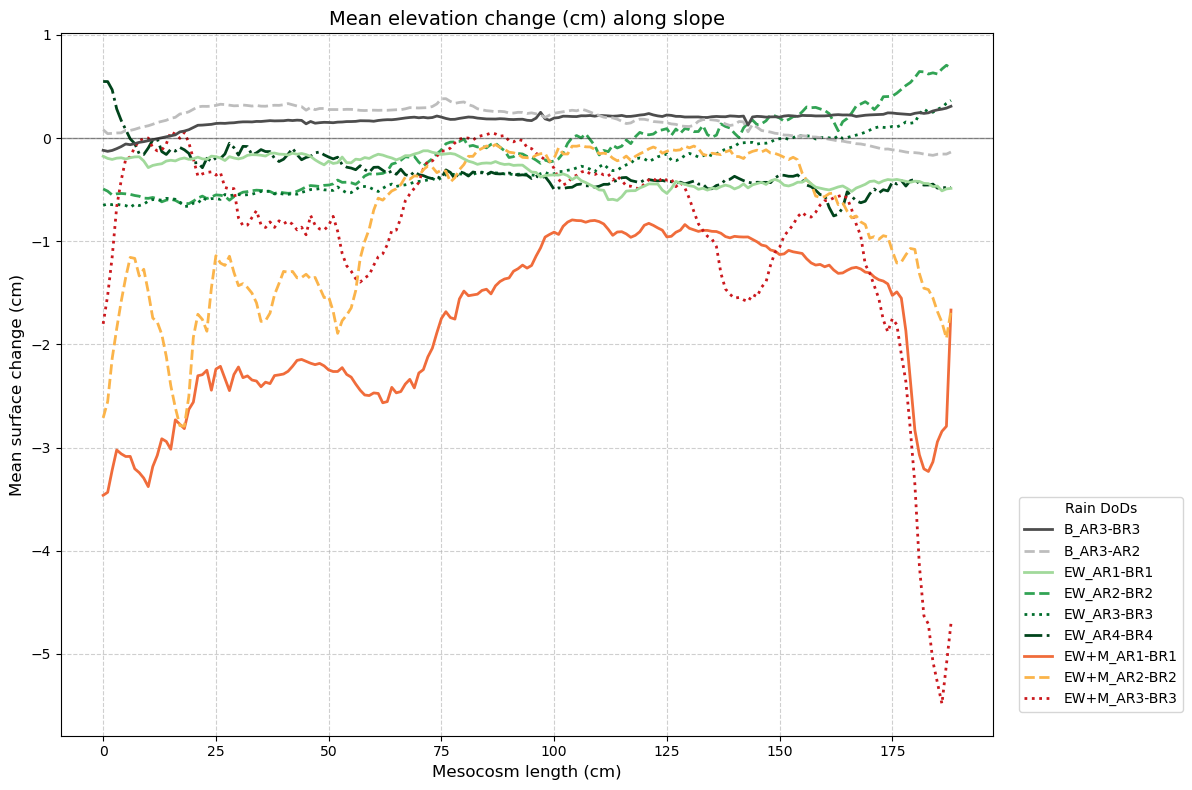

In [7]:
# 1. Create a figure and axis
plt.figure(figsize=(12, 8))
#fig, ax = plt.subplots(figsize=(14, 7), constrained_layout=True)

# Prepare style for figure
linestyle_mapping = {
    "B_AR3-BR3": "-",
    "B_AR3-AR2": "--",
    "EW_AR1-BR1": "-",
    "EW_AR2-BR2": "--",
    "EW_AR3-BR3": ":",
    'EW_AR4-BR4': "-.",
    "EW+M_AR1-BR1": "-",
    "EW+M_AR2-BR2": "--",
    "EW+M_AR3-BR3": ":"
}

color_mapping = {
    "B_AR3-BR3": "#4d4d4d",          # medium gray
    "B_AR3-AR2": "#bdbdbd",         # light gray
    
    "EW_AR1-BR1": "#a1d99b",        # light green
    "EW_AR2-BR2": "#31a354",        # medium green
    "EW_AR3-BR3": "#006d2c",        # dark green
    "EW_AR4-BR4": "#00441b",        # very dark green
    
    "EW+M_AR1-BR1": "#f06c3b",         # light red
    "EW+M_AR2-BR2": "#fbb44a",         # medium red
    "EW+M_AR3-BR3": "#cb181d"          # dark red
}
# 2. Iterate through the dictionary items

# name is the filename (key), df is the dataframe (value)
for name, df in surf_data.items():
    
    if 'mean_surf_change_row (m)' in df.columns:

         #get legend name
         legend_name = name_mapping.get(name, name)
         plt.plot(df['mean_surf_change_row (m)']*100, 
                  label=legend_name, 
                  linewidth=2, 
                  color=color_mapping.get(legend_name, 'black'), 
                  linestyle=linestyle_mapping.get(legend_name, '-'))
    else:
        print(f"Warning: 'mean_surf_change_row (m)' not found in {name}")

# 3. Add styling and labels
plt.title("Mean elevation change (cm) along slope", fontsize=14)
plt.xlabel("Mesocosm length (cm)", fontsize=12)
plt.ylabel("Mean surface change (cm)", fontsize=12) # Adjust unit as necessary

# 4. Add a legend to identify each file by color. To make the legend following the color and treatment order, I had to add a part to the code
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
# Define your desired order
desired_order = list(color_mapping.keys())  # same order as color_mapping
# Sort handles/labels according to desired_order
sorted_pairs = sorted(zip(labels, handles), key=lambda x: desired_order.index(x[0]) if x[0] in desired_order else 999)
sorted_labels, sorted_handles = zip(*sorted_pairs)
plt.legend(sorted_handles, sorted_labels, title="Rain DoDs", bbox_to_anchor=(1.02, 0.35))# or lower left, , ,loc='upper right'
plt.subplots_adjust(right=0.78)

plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.4) # Reference line at 0
plt.tight_layout() # Adjust layout to make room for legend

# 5. Save or show
#plt.savefig("surface_change_plot.png")
plt.show()

Plot net change but with average by treatment

Skipping or Warning: LoD_vs_LoD95_summary


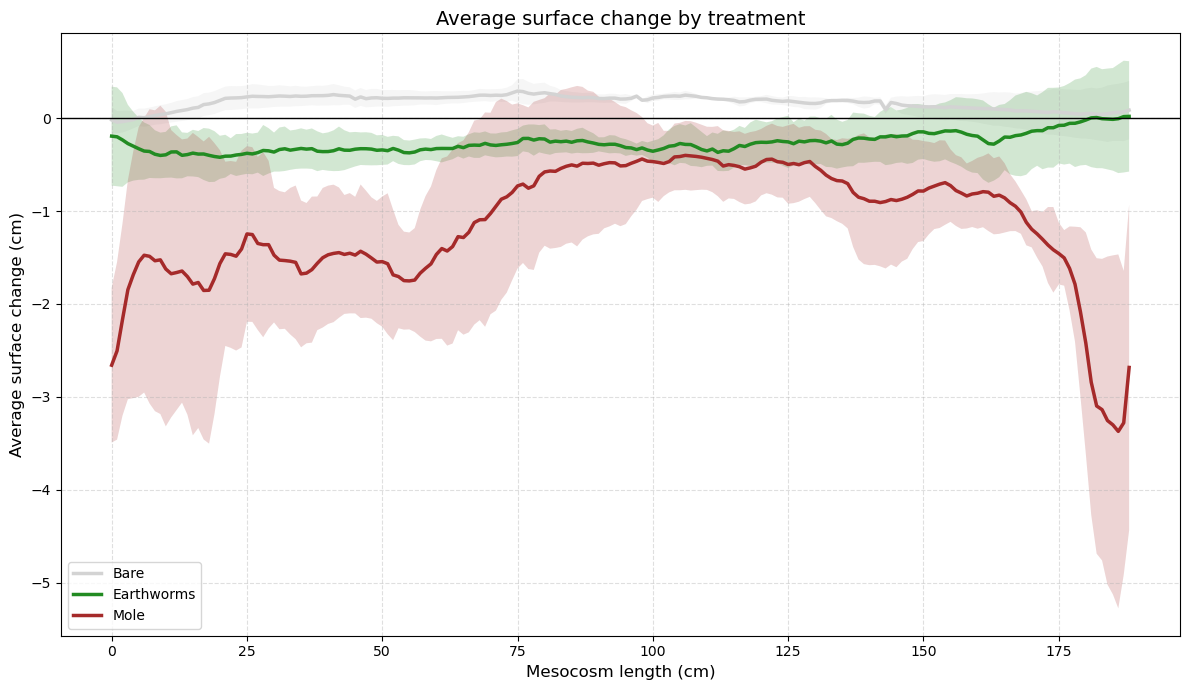

In [8]:
# 1. Setup grouping containers
treatment_groups = {'B': [], "EW": [], "EW+M": []}


# 2. Collect and group the data
for name, df in surf_data.items():
    run = name_mapping.get(name)
    
    if run and 'mean_surf_change_row (m)' in df.columns:
        
        # Extract treatment (before underscore)
        treatment = run.split("_")[0]
        
        series = df['mean_surf_change_row (m)'] * 100
        treatment_groups[treatment].append(series)
        
    else:
        print(f"Skipping or Warning: {name}")


# 3. Plotting
plt.figure(figsize=(12, 7))

colors = {"B": "lightgray", "EW": "forestgreen", "EW+M": "brown"}
labels = {"B": "Bare", "EW": "Earthworms", "EW+M": "Mole"}

for treat, series_list in treatment_groups.items():
    if not series_list:
        continue
    
    # Combine list of series into a single DataFrame to calculate mean/std row-wise
    combined_df = pd.concat(series_list, axis=1)
    
    avg_line = combined_df.mean(axis=1)
    std_dev = combined_df.std(axis=1)
    x_axis = combined_df.index # Assuming index represents mesocosm length

    # Plot the Mean Line
    plt.plot(x_axis, avg_line, label=labels[treat], color=colors[treat], linewidth=2.5)

    # Plot the Variance Shade (Mean +/- 1 Standard Deviation)
    plt.fill_between(x_axis, 
                     avg_line - std_dev, 
                     avg_line + std_dev, 
                     color=colors[treat], 
                     alpha=0.2, 
                     edgecolor='none')
# 4. Styling
plt.title("Average surface change by treatment", fontsize=14)
plt.xlabel("Mesocosm length (cm)", fontsize=12)
plt.ylabel("Average surface change (cm)", fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='-') # Reference line at 0
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()  

Surface change is here calculated as the difference in cm after and before a rainfall event, for each treatment. The data are taken from DoD calculated from the DEM with 1cm resolution. The DEMs were not detrended.

###  Volume change

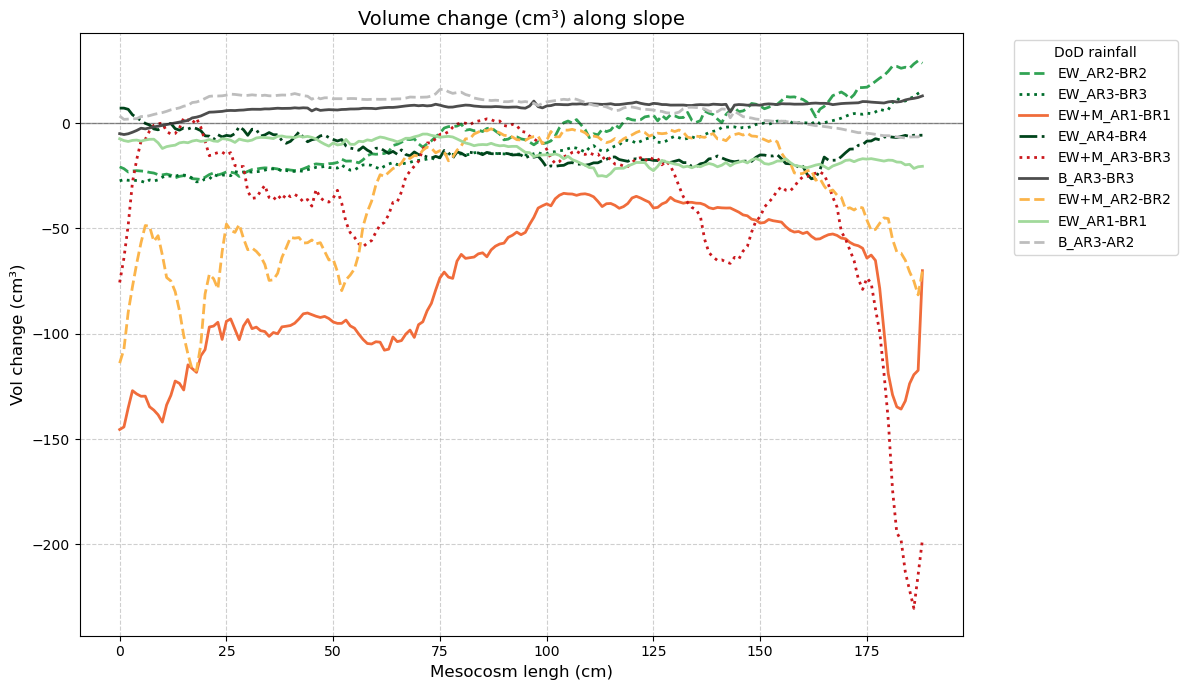

In [9]:
# 1. Create a figure and axis
plt.figure(figsize=(12, 7))

# Prepare visualization style for figure 
linestyle_mapping = {
    "B_AR3-BR3": "-",
    "B_AR3-AR2": "--",
    "EW_AR1-BR1": "-",
    "EW_AR2-BR2": "--",
    "EW_AR3-BR3": ":",
    'EW_AR4-BR4': "-.",
    "EW+M_AR1-BR1": "-",
    "EW+M_AR2-BR2": "--",
    "EW+M_AR3-BR3": ":"
}

color_mapping = {
    "B_AR3-BR3": "#4d4d4d",          # medium gray
    "B_AR3-AR2": "#bdbdbd",         # light gray
    "EW_AR1-BR1": "#a1d99b",        # light green
    "EW_AR2-BR2": "#31a354",        # medium green
    "EW_AR3-BR3": "#006d2c",        # dark green
    "EW_AR4-BR4": "#00441b",        # very dark green
    "EW+M_AR1-BR1": "#f06c3b",         # light red
    "EW+M_AR2-BR2": "#fbb44a",         # medium red
    "EW+M_AR3-BR3": "#cb181d"          # dark red
}

# 2. Iterate through the dictionary items
# name is the filename (key), df is the dataframe (value)
for name, df in surf_data.items():

    if 'vol_net_m3' in df.columns:

        legend_name = name_mapping.get(name, name)
        
        plt.plot(df['vol_net_m3']*1E+6, 
                 label=legend_name, 
                 linewidth=2, 
                 color=color_mapping.get(legend_name, 'black'), 
                 linestyle=linestyle_mapping.get(legend_name, '-'))
    else:
        print(f"Warning: 'vol_net_m3' not found in {name}")

# 3. Add styling and labels
plt.title("Volume change (cm³) along slope", fontsize=14)
plt.xlabel("Mesocosm lengh (cm)", fontsize=12)
plt.ylabel("Vol change (cm³)", fontsize=12) # Adjust unit as necessary

# 4. Add a legend to identify each file by color

# 4. Add a legend to identify each file by color. To make the legend following the color and treatment order, I had to add a part to the code
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
# Define your desired order
desired_order = list(color_mapping.keys())  # same order as color_mapping
# Sort handles/labels according to desired_order
sorted_pairs = sorted(zip(labels, handles), key=lambda x: desired_order.index(x[0]) if x[0] in desired_order else 999)
sorted_labels, sorted_handles = zip(*sorted_pairs)
plt.legend(title="DoD rainfall", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.4) # Reference line at 0
plt.tight_layout()

# 5. Save or show
#plt.savefig("surface_change_plot.png")
plt.show()

These results shall be read as: zero means that there is not change in surface volume from before and after rain. Positive value means an increment of surface volume, probably related to accumulation, negative is related to a decrease in surface volume, probably related to compaction or erosion. If erosion happen, there should be a positive value downslope that indicates the accumulation. 
*Bare soil*: almost no change. Very little possible erosion in the upslope, very small positive values along the rest of the slope. Possible soil redistribution. Values lower than limit of detection.

*Ew effect* : clear erosion-deposition pattern for the second event, with negative values upslope and positive values downslope. Similar pattern happens in the third event, with a smaller increment downslope. Event 1 and 4 show negative change along the slope. Event 1 has larger negative values towards the downslope. However, looking at the volume of soil excavated, that event is the one with the largest change downslope. An explanation of this is that water flow accumulated downlsope, and compacted more that part of the box. 
Event 4 indicates a small increment on the upper part of the slope, followed by a decrease, and another inrement towards the downslope. All the changes are negative. The positive value on the upper part might indicate animal activity during the event (more volume on the surface), the negative value in the middle part of the slope can show that compaction and collapse were the main process in place during the event. Positive trend but with negative values towards the downslope might indicate less impact of the rainfall event (possible higher infiltration?), and a possible less compaction, or eventual accumulation of soil coming from the middle part of the slope. 

*Mole effect*: this treatment include both mole and eathworms. The net volume change (after rain-before rain), if compared to the excavated volume by the animal before the rain, indicates a clear animal activity, and response to rainfall. The volume of soil excavated in the first 25 cm (upslope) of event 1, was the highest among all the mole events (almost 200 cm^3). However, the volume change of that area is the most negative. As we could witness during the event, the mound that was created in that part of the slope collapsed during the first rainfall. Another collapse, this time of a burrow, happened between 50 and 100 cm (middle slope). Compaction happened in the middle part of the slope, followed by another collapse in the front part of the slope. The second event with mole, present still a negative trend on the upper slope, but much less than the previous run. Comparing it with the excavated volume (around 100 cm^3 in the up slope), we can say that the mound that collapsed during the first event was refilled, and new soil was brought to the surface. This soil in that location was probably more compact (or wet), as the change in volume, although still negative, was less than the previous treatment. Not much change happened in the middle, indicating that the previous collapse was in some way stabilized. The downslope collapse was filled with new soil. This is reflected by the net volume that is similar to the net volume of event 1 downslope, and by the fact that the difference in volume change is less that the previous one. 
During the third event, the volume representing the mound on the upperslope did not change, while the burrow seems collapsing again. Looking at the net volume, around the 50 cm of the box, there is still a clear collapse. This collapse seems stable from the volume change, but followed by another collapse around 60 cm. On the downslope, the burrow that was re-filled in the second event, during the third event collapsed again, creating even a larger negative volume change than before. 

If we relate this with soil moisture, the compaction during the second event can have increased the surface soil moisture, and therefore also the soil weight. This caused the second collapse during the third event.

Therefore, with animals, we can see a sequence of: excavation- collapse- excavation- compaction- collapse.

To be sure that this interpretation is true, I need to check the soil moisture content in the first 5 to 15 cm, before and after the rainfall event.


- After having checked moisture before and after 

This results indicate that after the rain there was more compaction rather than distribution over the slope,at least for the mole treatment. 
Bare soil has no if little change in surface volume. 
 in cases where the value is very low (see Mole 3 event), it can be related to the burrow collapse.

### Visualization of average volume

Skipping or Warning: LoD_vs_LoD95_summary


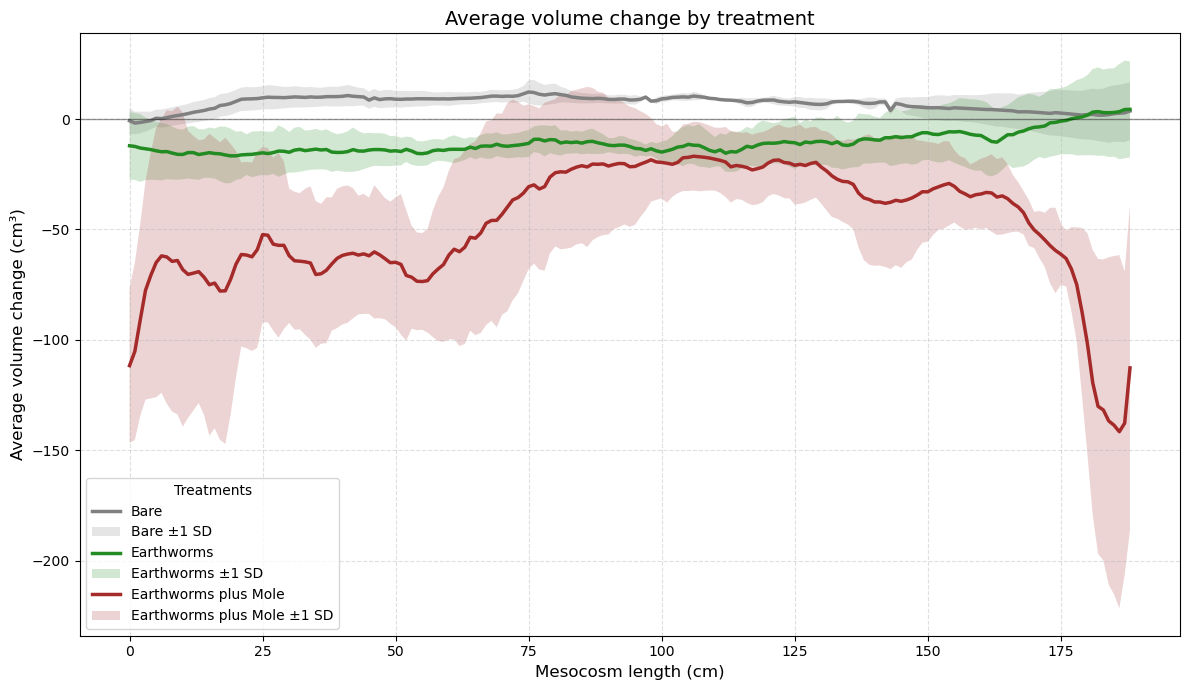

In [11]:
# 1. Setup grouping containers
treatment_groups = {'B': [], "EW": [], "EW+M": []}


# 2. Collect and group the data
for name, df in surf_data.items():
    run = name_mapping.get(name)
    
    if run and 'vol_net_m3' in df.columns:
        
        # Extract treatment (before underscore)
        treatment = run.split("_")[0]
        
        series = df['vol_net_m3'] * 1E+6
        treatment_groups[treatment].append(series)
        
    else:
        print(f"Skipping or Warning: {name}")


# 3. Plotting
plt.figure(figsize=(12, 7))

colors = {"B": "gray", "EW": "forestgreen", "EW+M": "brown"}
labels = {"B": "Bare", "EW": "Earthworms", "EW+M": "Earthworms plus Mole"}

for treat, series_list in treatment_groups.items():
    if not series_list:
        continue
    
    # Combine list of series into a single DataFrame to calculate mean/std row-wise
    combined_df = pd.concat(series_list, axis=1)
    
    avg_line = combined_df.mean(axis=1)
    std_dev = combined_df.std(axis=1)
    x_axis = combined_df.index # Assuming index represents mesocosm length

    # Plot the Mean Line
    plt.plot(x_axis, avg_line, label=labels[treat], color=colors[treat], linewidth=2.5)

    # Plot the Variance Shade (Mean +/- 1 Standard Deviation)
    plt.fill_between(x_axis, 
                     avg_line - std_dev, 
                     avg_line + std_dev, 
                     color=colors[treat], 
                     alpha=0.2, 
                     edgecolor='none',
                     label=f"{labels[treat]} ±1 SD")
# 4. Styling
plt.title("Average volume change by treatment", fontsize=14)
plt.xlabel("Mesocosm length (cm)", fontsize=12)
plt.ylabel("Average volume change (cm³)", fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='-',alpha=0.4) # Reference line at 0
plt.legend(title="Treatments",loc='lower left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()  

### Fit a linear model over the means


Bare Model: Slope=-0.0409, R²=0.671
Earthworms Model: Slope=0.0540, R²=0.644
Earthworms plus Mole Model: Slope=0.2603, R²=0.383


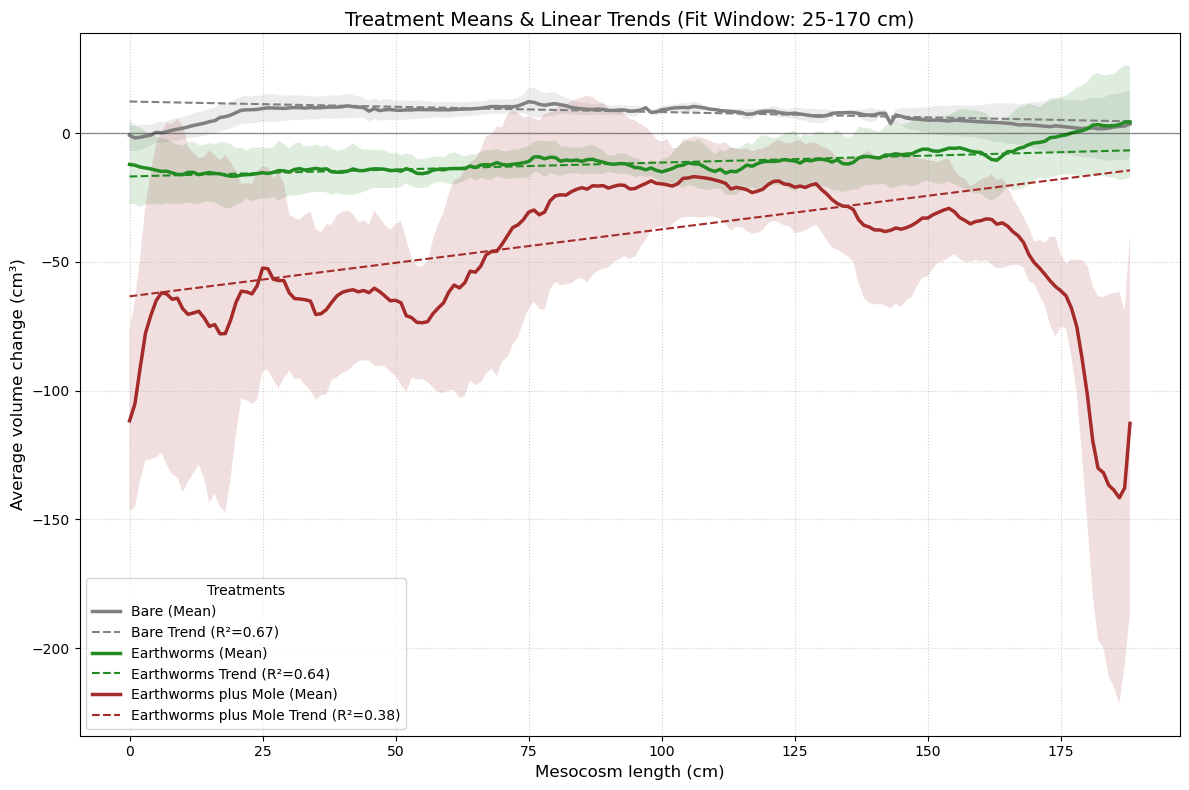

In [12]:

# 1. SETTINGS
X_MIN, X_MAX = 25, 170
colors = {"B": "gray", "EW": "forestgreen", "EW+M": "brown"}
labels = {"B": "Bare", "EW": "Earthworms", "EW+M": "Earthworms plus Mole"}

plt.figure(figsize=(12, 8))

# 2. PROCESS EACH TREATMENT GROUP
for treat, series_list in treatment_groups.items():
    if not series_list:
        continue
    
    # --- Step A: Calculate the Treatment Mean ---
    # Combine individual runs into one DF and calculate mean/std
    combined_df = pd.concat(series_list, axis=1)
    avg_line = combined_df.mean(axis=1)
    std_dev = combined_df.std(axis=1)
    x_axis = combined_df.index.values # Convert to numpy array for masking
    
    # --- Step B: Fit Linear Model to the Mean Line ---
    # Create a mask for the window (25-170cm) and handle NaNs
    mask = (x_axis >= X_MIN) & (x_axis <= X_MAX) & (~np.isnan(avg_line))
    
    if np.any(mask):
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            x_axis[mask], 
            avg_line[mask]
        )
        
        # Create the trendline (calculated over the full x_axis for plotting)
        trend_line = slope * x_axis + intercept
        
        # --- Step C: Visualization ---
        # 1. Plot the Variance Shade (Mean +/- 1 SD)
        plt.fill_between(x_axis, 
                         avg_line - std_dev, 
                         avg_line + std_dev, 
                         color=colors[treat], 
                         alpha=0.15, 
                         edgecolor='none')

        # 2. Plot the Average Line
        plt.plot(x_axis, avg_line, 
                 color=colors[treat], 
                 linewidth=2.5, 
                 label=f"{labels[treat]} (Mean)")

        # 3. Plot the Linear Model (Trendline)
        # We use a dashed line to distinguish it from the mean
        plt.plot(x_axis, trend_line, 
                 color=colors[treat], 
                 linestyle='--', 
                 linewidth=1.5,
                 label=f"{labels[treat]} Trend (R²={r_value**2:.2f})")
        
        print(f"{labels[treat]} Model: Slope={slope:.4f}, R²={r_value**2:.3f}")

# 3. STYLING
#plt.axvspan(X_MIN, X_MAX, color='yellow', alpha=0.05, label="Fit Window")
plt.axhline(0, color='black', linewidth=1, alpha=0.4)

plt.title(f"Treatment Means & Linear Trends (Fit Window: {X_MIN}-{X_MAX} cm)", fontsize=14)
plt.xlabel("Mesocosm length (cm)", fontsize=12)
plt.ylabel("Average volume change (cm³)", fontsize=12)

# Adjust legend to be outside if it gets too crowded
plt.legend(title = "Treatments", loc='lower left')#, bbox_to_anchor=(1, 1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

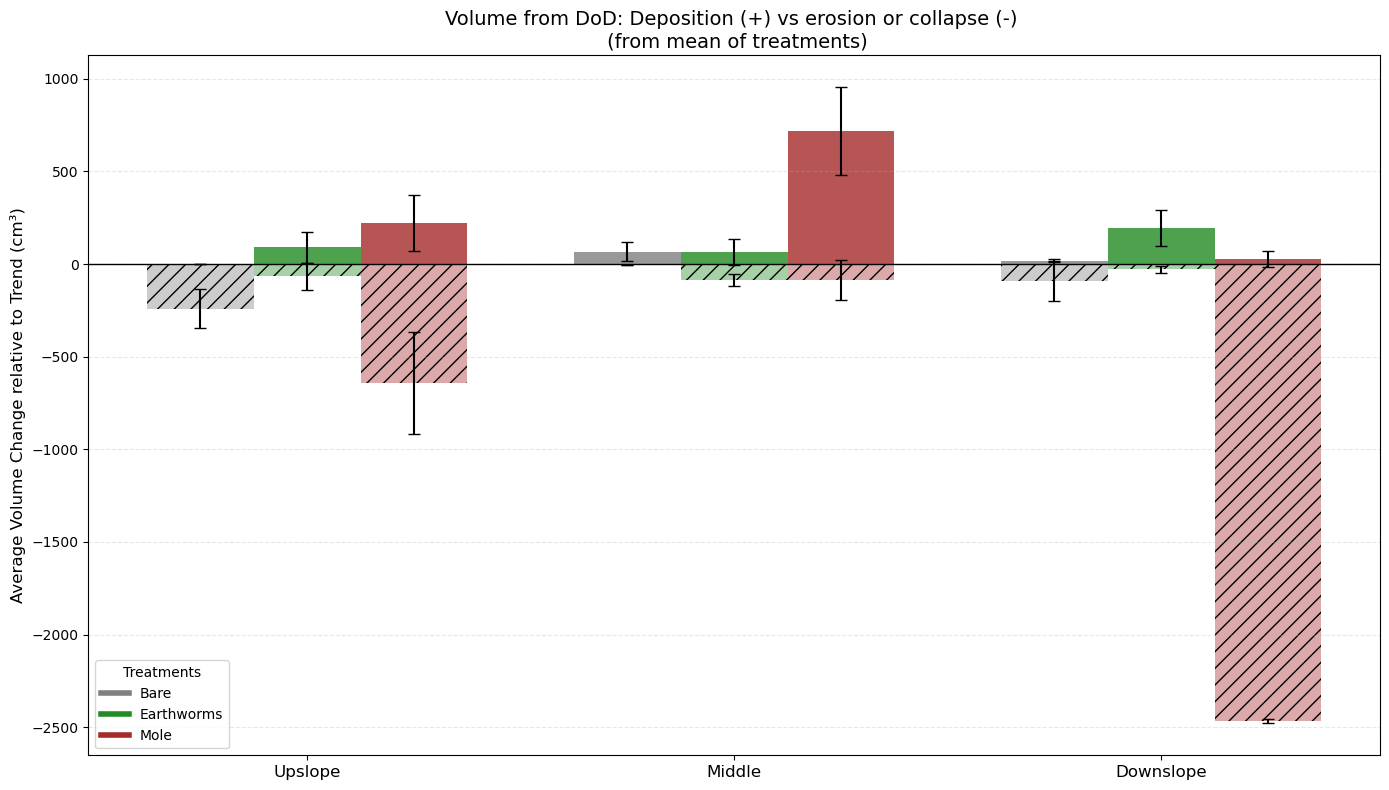

 Treatment      Zone  Above_Mean  Above_Std  Below_Mean  Below_Std
      Bare Downslope   18.700557   8.878630   90.098158 107.559271
      Bare    Middle   66.413756  51.591954    4.058132   1.335382
      Bare   Upslope    0.760365   1.075318  240.713623 105.455299
Earthworms Downslope  194.397550  98.433925   29.343123  17.184978
Earthworms    Middle   65.807976  71.705824   88.288171  32.308452
Earthworms   Upslope   89.759205  82.328942   67.005926  71.556745
      Mole Downslope   26.507588  41.463098 2466.331256  13.213741
      Mole    Middle  717.718143 237.045770   87.445797 107.027435
      Mole   Upslope  223.401753 150.933891  644.118552 275.359509


In [13]:
# 1. Setup Parameters
# Get max length across all runs to define unified zones
all_max_x = []
for name in name_mapping:
    if name in surf_data:
        all_max_x.append(surf_data[name].index.max())
max_l = max(all_max_x)

zones = {
    "Upslope": (0, max_l/3),
    "Middle": (max_l/3, 2*max_l/3),
    "Downslope": (2*max_l/3, max_l)
}
labels = {"B": "Bare", "EW": "Earthworms", "EW+M": "Mole"}
individual_zonal_data = []

# 2. Process Every Individual Run
for name, legend_name in name_mapping.items():
    if name not in surf_data: continue
    
    df = surf_data[name]
    x_axis = df.index.values
    y_raw = df['vol_net_m3'] * 1e6  # Convert to cm3
    
    
    # Identify treatment category
    if legend_name.startswith("EW+M"): treat_cat = "EW+M"
    elif legend_name.startswith("EW"): treat_cat = "EW"
    else: treat_cat = "B"

    # --- Step A: Fit Model for the Run ---
    
    if treat_cat == "EW+M":
        f_start, f_end = 25, 150
    else:
        f_start, f_end = 25, 170
    
    mask_fit = (x_axis >= f_start) & (x_axis <= f_end) & (~np.isnan(y_raw))
    
    # Safety check: ensure we have data in the window
    if np.sum(mask_fit) > 2:
        res = stats.linregress(x_axis[mask_fit], y_raw[mask_fit])
        y_fit = res.slope * x_axis + res.intercept
        diff = y_raw - y_fit
    else:
        continue # Skip if window is empty

    # --- Step B: Calculate Vol for each Zone ---
    for zone_name, (z_start, z_end) in zones.items():
        z_mask = (x_axis >= z_start) & (x_axis <= z_end) & (~np.isnan(diff))
        if np.sum(z_mask) < 2: continue
        
        x_z = x_axis[z_mask]
        diff_z = diff[z_mask]
        
        vol_above = np.trapz(np.where(diff_z > 0, diff_z, 0), x_z)
        vol_below = np.trapz(np.where(diff_z < 0, np.abs(diff_z), 0), x_z)
        
        individual_zonal_data.append({
            'Run': legend_name,
            'Treatment': labels[treat_cat],
            'Zone': zone_name,
            'Vol_Above': vol_above,
            'Vol_Below': vol_below
        })

# 3. Aggregate Results (Mean and SD)
df_zonal = pd.DataFrame(individual_zonal_data)
summary = df_zonal.groupby(['Treatment', 'Zone']).agg({
    'Vol_Above': ['mean', 'std'],
    'Vol_Below': ['mean', 'std']
}).reset_index()

# Flatten columns: 'Vol_Above_mean', 'Vol_Above_std', etc.
summary.columns = ['Treatment', 'Zone', 'Above_Mean', 'Above_Std', 'Below_Mean', 'Below_Std']

# 4. Visualization: Grouped Bar Chart with Error Bars
fig, ax = plt.subplots(figsize=(14, 8))

treatments_list = ["Bare", "Earthworms", "Mole"]
zone_list = ["Upslope", "Middle", "Downslope"]
colors_map = {"Bare": "gray", "Earthworms": "forestgreen", "Mole": "brown"}

x = np.arange(len(zone_list))
width = 0.25  # Width of each bar group

for i, treat in enumerate(treatments_list):
    # Filter data for this treatment
    t_data = summary[summary['Treatment'] == treat].set_index('Zone').reindex(zone_list)
    
    offset = (i - 1) * width
    
    # Plot Positive Volume (Above)
    ax.bar(x + offset, t_data['Above_Mean'], width, yerr=t_data['Above_Std'],
           label=f"{treat} (Deposition)", color=colors_map[treat], alpha=0.8, capsize=4)
    
    # Plot Negative Volume (Below) - shown as negative bars for clarity
    ax.bar(x + offset, -t_data['Below_Mean'], width, yerr=t_data['Below_Std'],
           color=colors_map[treat], alpha=0.4, hatch='//', capsize=4)

# Styling
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(zone_list, fontsize=12)
ax.set_ylabel("Average Volume Change relative to Trend (cm³)", fontsize=12)
ax.set_title("Volume from DoD: Deposition (+) vs erosion or collapse (-) \n (from mean of treatments)", fontsize=14)

# Custom legend to simplify
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=colors_map[t], lw=4, label=t) for t in treatments_list]
ax.legend(handles=legend_elements, title="Treatments", loc='lower left')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Display the numerical table for your records
print(summary.to_string(index=False))

## Fit linear model single runs

In this step, first fit the linear model over each run, calculate the positive and negative volume, and finally averaging them. 
The workflow is:
1. Loop through every individual  DoD run.

2. Fit a unique linear model for that specific run.

3. Integrate the Area Above/Below for that specific run.

4. Group the results by treatment and Average them.

Model for B_AR3-BR3: Slope = 0.0202, Intercept = 6.11
Model for B_AR3-AR2: Slope = -0.1020, Intercept = 18.53


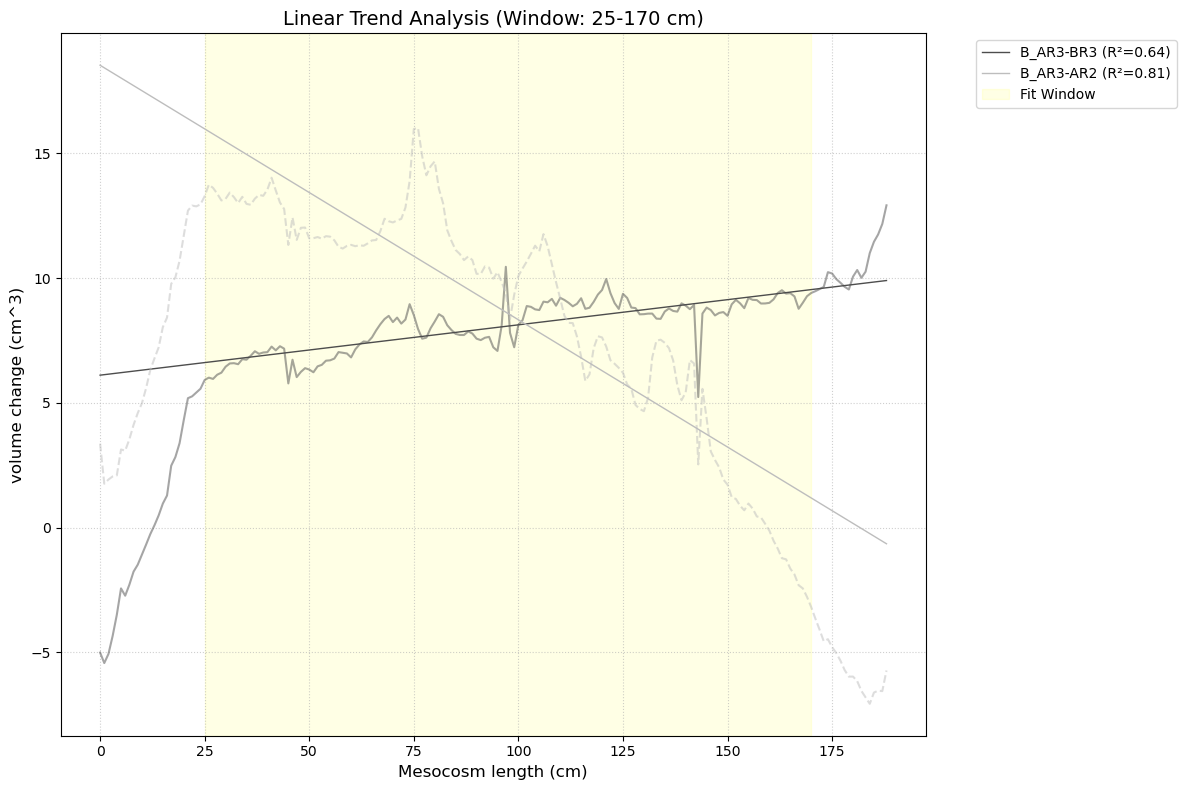

In [21]:
# 1. SETTINGS: Choose which runs to plot and the window
# Example: Only look at the Bare control and the third Earthworm replicate
RUNS_TO_PLOT = [ 'B_AR3-BR3', 'B_AR3-AR2','M_AR3-BR3' ]  
# Names in the name_plotting to be used:
#{'DoD_1cm_clip_6fill_align-clip_5fill_align': 'B_AR3-BR3',
# 'DoD_1cm_clip_6fill_align-4_mask_filled': 'B_AR3-AR2',
# 'DoD_1cm_clip_11-10': 'EW_AR1-BR1',
# 'DoD_1cm_clip_13-12': 'EW_AR2-BR2',
# 'DoD_1cm_clip_15-14': 'EW_AR3-BR3',
# 'DoD_1cm_clip_17-16': 'EW_AR4-BR4',
# 'DoD_1cm_clip_21-20': 'M_AR1-BR1',
# 'DoD_1cm_clip_23-22': 'M_AR2-BR2',
# 'DoD_1cm_clip_25-24': 'M_AR3-BR3'}

# Define your fitting window (e.g., ignoring the first and last 10cm)
X_MIN, X_MAX = 25, 170

plt.figure(figsize=(12, 8))

for name, legend_name in name_mapping.items():
    # Only process if it's in our "to plot" list
    if legend_name not in RUNS_TO_PLOT:
        continue
        
    if name in surf_data:
        df = surf_data[name]
        
        # Data preparation (Index is our X, vol_net_m3 * 1e6 is our Y)
        x_axis = df.index.values
        y_values = df['vol_net_m3'] * 1e6
        
        # --- STEP 1: APPLY WINDOW MASK ---
        # Filter data for the linear fit based on X_MIN and X_MAX
        mask = (x_axis >= X_MIN) & (x_axis <= X_MAX) & (~np.isnan(y_values))
        
        if np.any(mask):
            # --- STEP 2: FIT LINEAR MODEL ---
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                x_axis[mask], 
                y_values[mask]
            )
            
            # Create the trendline for the FULL length of the data
            line = slope * x_axis + intercept
            
            # --- STEP 3: PLOT RAW DATA AND MODEL ---
            # Plot raw data
            plt.plot(x_axis, y_values, 
                     color=color_mapping[legend_name], 
                     linestyle=linestyle_mapping[legend_name], 
                     alpha=0.5, linewidth=1.5)
            
            # Plot the Linear Model 
            plt.plot(x_axis, line, 
                     color=color_mapping[legend_name], 
                     label=f"{legend_name} (R²={r_value**2:.2f})", 
                     linewidth=1)
            
            print(f"Model for {legend_name}: Slope = {slope:.4f}, Intercept = {intercept:.2f}")

# Visual indicators for the window used
plt.axvspan(X_MIN, X_MAX, color='yellow', alpha=0.1, label="Fit Window")

# Styling
plt.title(f"Linear Trend Analysis (Window: {X_MIN}-{X_MAX} cm)", fontsize=14)
plt.xlabel("Mesocosm length (cm)", fontsize=12)
plt.ylabel("volume change (cm^3)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

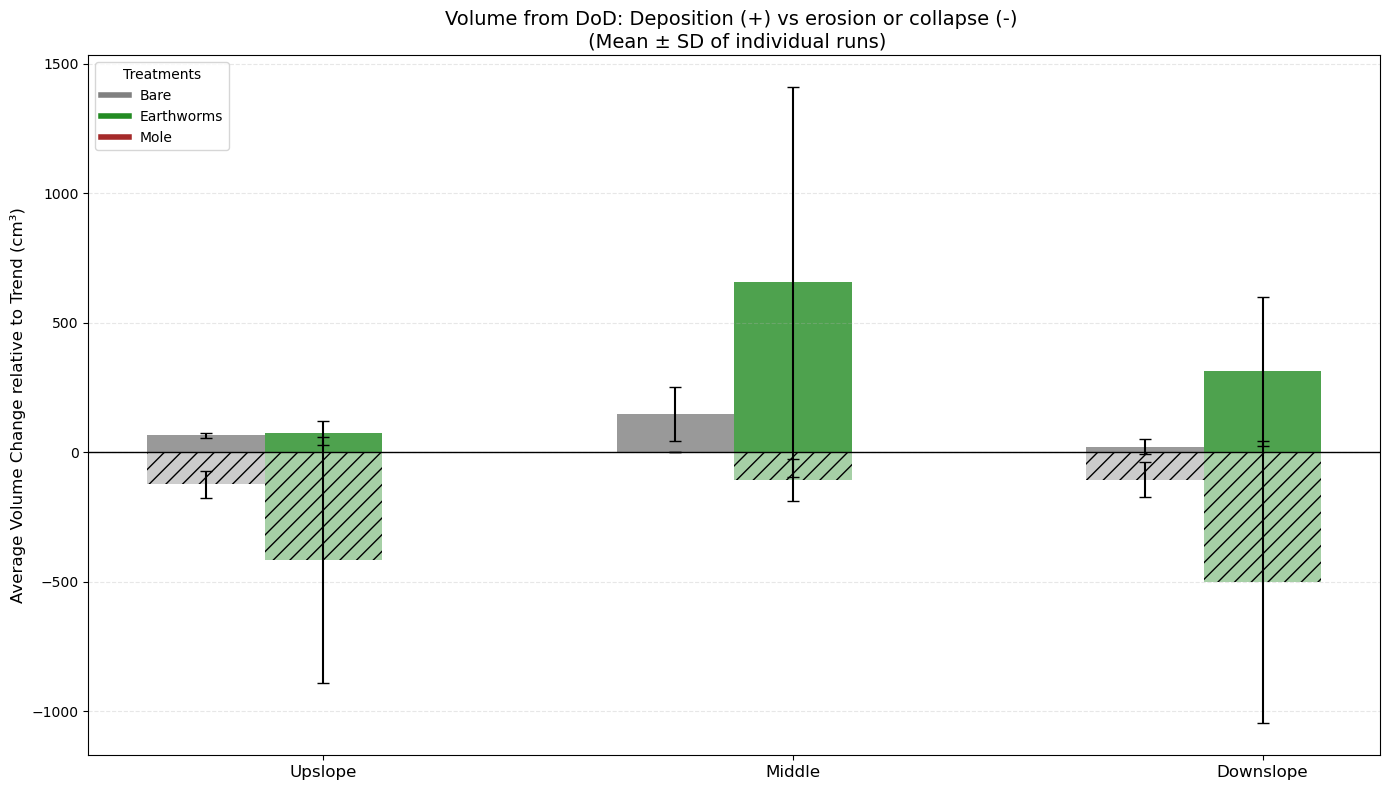

 Treatment      Zone  Above_Mean  Above_Std  Below_Mean  Below_Std
      Bare Downslope   21.562887  27.890789  105.871802  67.865435
      Bare    Middle  146.580323 104.260780    0.231086   0.326806
      Bare   Upslope   64.834489   9.980116  123.889210  51.935997
Earthworms Downslope  311.861359 288.709335  502.446579 544.916363
Earthworms    Middle  657.527123 752.003312  107.002475  81.086586
Earthworms   Upslope   74.697109  45.921051  416.231608 476.092644


In [22]:
# 1. Setup Parameters
# Get max length across all runs to define unified zones
all_max_x = []
for name in name_mapping:
    if name in surf_data:
        all_max_x.append(surf_data[name].index.max())
max_l = max(all_max_x)

zones = {
    "Upslope": (0, max_l/3),
    "Middle": (max_l/3, 2*max_l/3),
    "Downslope": (2*max_l/3, max_l)
}

individual_zonal_data = []

# 2. Process Every Individual Run
for name, legend_name in name_mapping.items():
    if name not in surf_data: continue
    
    df = surf_data[name]
    x_axis = df.index.values
    y_raw = df['vol_net_m3'] * 1e6  # Convert to cm3
    labels = {"B": "Bare", "EW": "Earthworms", "M": "Mole"}
    
    # Identify treatment category
    if legend_name.startswith("EW"): treat_cat = "EW"
    elif legend_name.startswith("M"): treat_cat = "M"
    else: treat_cat = "B"

    # --- Step A: Fit Model for the Run ---
    f_start, f_end = (25, 170) if treat_cat == "M" else (x_axis.min(), x_axis.max())# Fit a window over the mole treatment
    #f_start, f_end = (25, 175) if treat_cat == "EW4" else (x_axis.min(), x_axis.max())# modify it for EW4, which is the one with the most different pattern
    mask_fit = (x_axis >= f_start) & (x_axis <= f_end) & (~np.isnan(y_raw))
    res = stats.linregress(x_axis[mask_fit], y_raw[mask_fit])
    
    y_fit = res.slope * x_axis + res.intercept
    diff = y_raw - y_fit

    # --- Step B: Calculate Vol for each Zone ---
    for zone_name, (z_start, z_end) in zones.items():
        z_mask = (x_axis >= z_start) & (x_axis <= z_end) & (~np.isnan(diff))
        if np.sum(z_mask) < 2: continue
        
        x_z = x_axis[z_mask]
        diff_z = diff[z_mask]
        
        vol_above = np.trapz(np.where(diff_z > 0, diff_z, 0), x_z)
        vol_below = np.trapz(np.where(diff_z < 0, np.abs(diff_z), 0), x_z)
        
        individual_zonal_data.append({
            'Run': legend_name,
            'Treatment': labels[treat_cat],
            'Zone': zone_name,
            'Vol_Above': vol_above,
            'Vol_Below': vol_below
        })

# 3. Aggregate Results (Mean and SD)
df_zonal = pd.DataFrame(individual_zonal_data)
summary = df_zonal.groupby(['Treatment', 'Zone']).agg({
    'Vol_Above': ['mean', 'std'],
    'Vol_Below': ['mean', 'std']
}).reset_index()

# Flatten columns: 'Vol_Above_mean', 'Vol_Above_std', etc.
summary.columns = ['Treatment', 'Zone', 'Above_Mean', 'Above_Std', 'Below_Mean', 'Below_Std']

# 4. Visualization: Grouped Bar Chart with Error Bars
fig, ax = plt.subplots(figsize=(14, 8))

treatments_list = ["Bare", "Earthworms", "Mole"]
zone_list = ["Upslope", "Middle", "Downslope"]
colors_map = {"Bare": "gray", "Earthworms": "forestgreen", "Mole": "brown"}

x = np.arange(len(zone_list))
width = 0.25  # Width of each bar group

for i, treat in enumerate(treatments_list):
    # Filter data for this treatment
    t_data = summary[summary['Treatment'] == treat].set_index('Zone').reindex(zone_list)
    
    offset = (i - 1) * width
    
    # Plot Positive Volume (Above)
    ax.bar(x + offset, t_data['Above_Mean'], width, yerr=t_data['Above_Std'],
           label=f"{treat} (Deposition)", color=colors_map[treat], alpha=0.8, capsize=4)
    
    # Plot Negative Volume (Below) - shown as negative bars for clarity
    ax.bar(x + offset, -t_data['Below_Mean'], width, yerr=t_data['Below_Std'],
           color=colors_map[treat], alpha=0.4, hatch='//', capsize=4)

# Styling
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(zone_list, fontsize=12)
ax.set_ylabel("Average Volume Change relative to Trend (cm³)", fontsize=12)
ax.set_title("Volume from DoD: Deposition (+) vs erosion or collapse (-) \n (Mean ± SD of individual runs)", fontsize=14)

# Custom legend to simplify
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=colors_map[t], lw=4, label=t) for t in treatments_list]
ax.legend(handles=legend_elements, title="Treatments", loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Display the numerical table for your records
print(summary.to_string(index=False))

# 2. Soil displaced directly by animal activity

I used the last raster of surface bare, and then subtracted it to the value related to the before event of each run.

## Import data 

In [ ]:
folder_path1_a = pathlib.Path("C:\\Animal_disturbance_csv_z")

<>:1: SyntaxWarning: invalid escape sequence '\E'
<>:1: SyntaxWarning: invalid escape sequence '\E'
C:\Users\loreg001\AppData\Local\Temp\ipykernel_20616\3951610726.py:1: SyntaxWarning: invalid escape sequence '\E'
  folder_path1_a = pathlib.Path("W:\ESG\DOW_SLM\PhD_projects\Marta_Loreggian\Spatial_analysis_py\mesocosm_spatial_analysis\Animal_disturbance_csv")


In [24]:
# Create a dictionary
# Dictionary to store dataframes: { 'filename': dataframe }
surf_data_animal = {}

# Loop through all CSVs in the folder
for file in folder_path1_a.glob("*.csv"):
    # Read the CSV and store it with the filename as the key
    surf_data_animal[file.stem] = pd.read_csv(file)

print(f"Successfully loaded {len(surf_data_animal)} DoD files.")

Successfully loaded 14 DoD files.


## 2.1 Plot

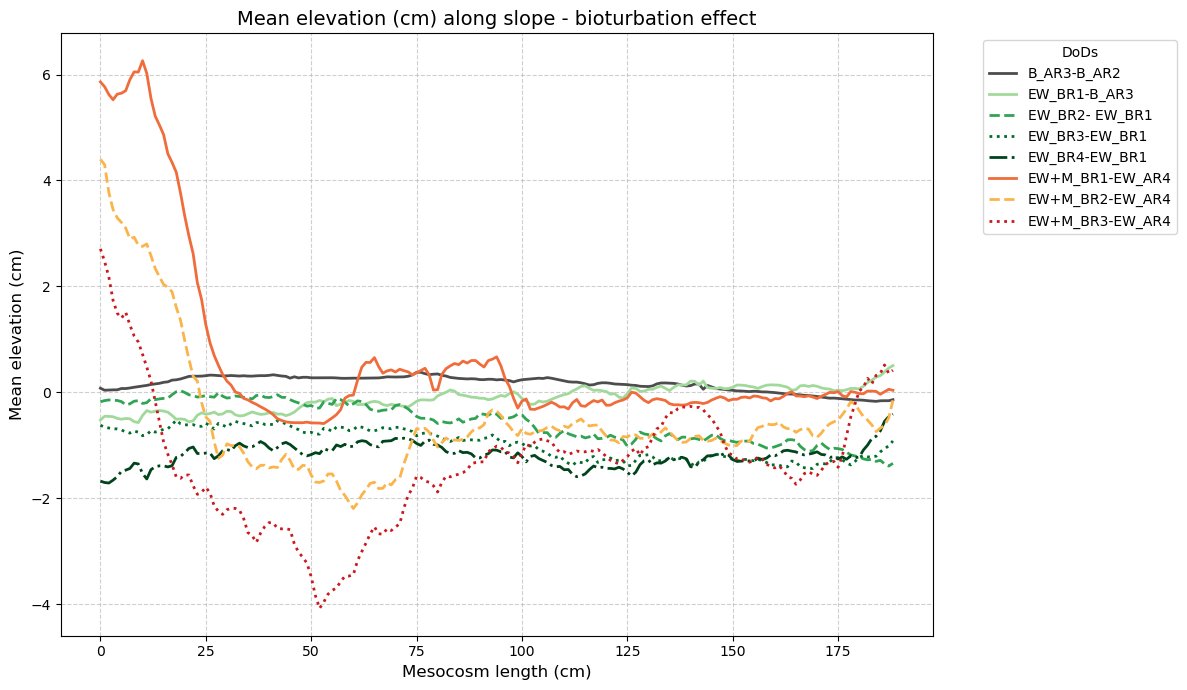

In [25]:
# 1. Create a figure and axis
plt.figure(figsize=(12, 7))

# 2. Iterate through the dictionary items. As I have different csv and I want to choose only some, I will create here a mapping dictionary to assign the name I want to the legend. I will use the name of the file as key and the legend name as value.
animal_treatment_mapping = {

    "DoD_1cm_clip_6fill_align-4_mask_filled": "B_AR3-B_AR2",
    "DoD_1cm_clip_10align-6": "EW_BR1-B_AR3",
    "DoD_1cm_clip_12-10": "EW_BR2- EW_BR1",
    'DoD_1cm_clip_14-10': "EW_BR3-EW_BR1",
    'DoD_1cm_clip_16_masked-10': "EW_BR4-EW_BR1",
    'DoD_1cm_clip_20-17': "EW+M_BR1-EW_AR4",# first mole event minus the DEM from the last EW run 
    'DoD_1cm_clip_22-17': "EW+M_BR2-EW_AR4",
    'DoD_1cm_clip_24-17': "EW+M_BR3-EW_AR4"

}
# Prepare style for figure
linestyle_mapping = {
    "B_AR3-B_AR2": "-",
    "EW_BR1-B_AR3": "-",
    "EW_BR2- EW_BR1": "--",
    "EW_BR3-EW_BR1": ":",
    'EW_BR4-EW_BR1': "-.",
    "EW+M_BR1-EW_AR4": "-",
    "EW+M_BR2-EW_AR4": "--",
    "EW+M_BR3-EW_AR4": ":"
}

color_mapping = {
    "B_AR3-B_AR2": "#4d4d4d",          # medium gray
    #"B_AR3-AR2": "#bdbdbd",         # light gray
    
    "EW_BR1-B_AR3": "#a1d99b",        # light green
    "EW_BR2- EW_BR1": "#31a354",        # medium green
    "EW_BR3-EW_BR1": "#006d2c",        # dark green
    "EW_BR4-EW_BR1": "#00441b",        # very dark green
    
    "EW+M_BR1-EW_AR4": "#f06c3b",         # light red
    "EW+M_BR2-EW_AR4": "#fbb44a",         # medium red
    "EW+M_BR3-EW_AR4": "#cb181d"          # dark red
}

# To iterate along the data that are in the dictionary and plot only those that I want, I will use the mapping dictionary to check if the name of the file is in the dictionary and then plot it with the name I want in the legend.
for name, legend_name in animal_treatment_mapping.items():
    
    # Check if that file exists in your dictionary
    if name in surf_data_animal:
        df = surf_data_animal[name]
        
        if 'mean_surf_change_row (m)' in df.columns:
            plt.plot(
                df['mean_surf_change_row (m)'] * 100,
                label=legend_name,
                linewidth=2,
                color=color_mapping.get(legend_name, 'black'), 
                linestyle=linestyle_mapping.get(legend_name, '-')
            )
        else:
            print(f"Warning: Column not found in {name}")
    else:
        print(f"Warning: {name} not found in surf_data_animal")

plt.title("Mean elevation (cm) along slope - bioturbation effect", fontsize=14)
plt.xlabel("Mesocosm length (cm)", fontsize=12)
plt.ylabel("Mean elevation (cm)", fontsize=12)

plt.legend(title="DoDs", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Plot volumes

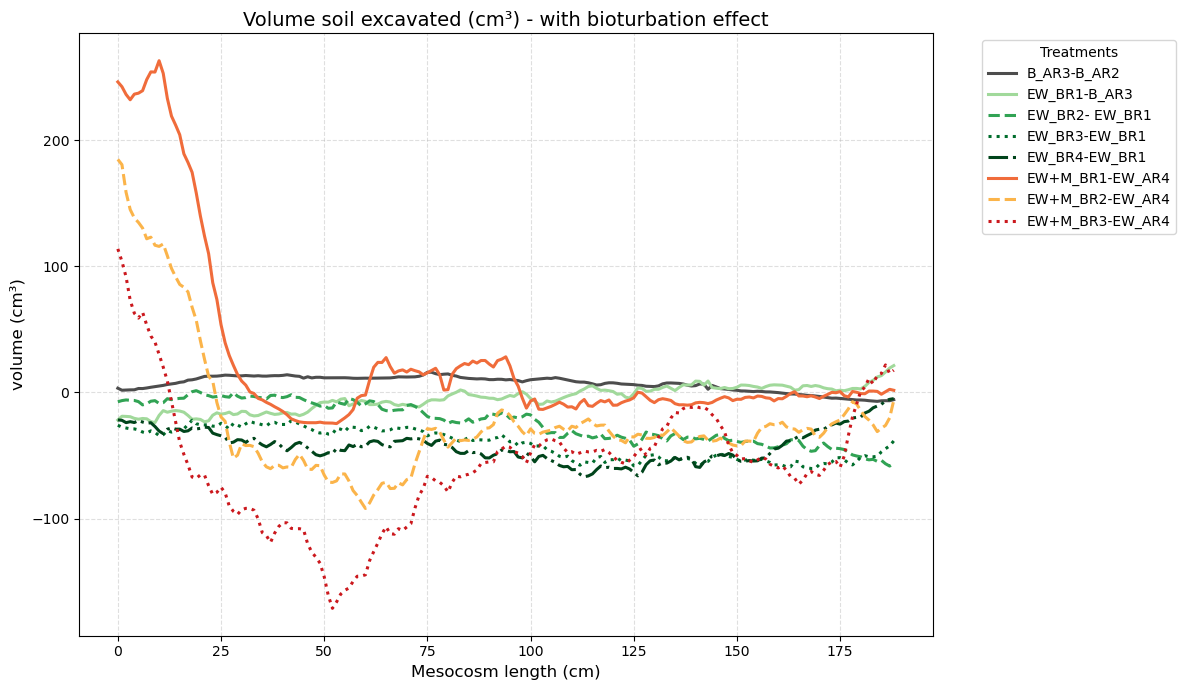

In [26]:
# 1. Create a figure and axis
plt.figure(figsize=(12, 7))

animal_treatment_mapping = {

    "DoD_1cm_clip_6fill_align-4_mask_filled": "B_AR3-B_AR2",
    "DoD_1cm_clip_10align-6": "EW_BR1-B_AR3",
    "DoD_1cm_clip_12-10": "EW_BR2- EW_BR1",
    'DoD_1cm_clip_14-10': "EW_BR3-EW_BR1",
    'DoD_1cm_clip_16_masked-10': "EW_BR4-EW_BR1",
    'DoD_1cm_clip_20-17': "EW+M_BR1-EW_AR4",# first mole event minus the DEM from the last EW run 
    'DoD_1cm_clip_22-17': "EW+M_BR2-EW_AR4",
    'DoD_1cm_clip_24-17': "EW+M_BR3-EW_AR4"

}
# Prepare style for figure
linestyle_mapping = {
    "B_AR3-B_AR2": "-",
    "EW_BR1-B_AR3": "-",
    "EW_BR2- EW_BR1": "--",
    "EW_BR3-EW_BR1": ":",
    'EW_BR4-EW_BR1': "-.",
    "EW+M_BR1-EW_AR4": "-",
    "EW+M_BR2-EW_AR4": "--",
    "EW+M_BR3-EW_AR4": ":"
}

color_mapping = {
    "B_AR3-B_AR2": "#4d4d4d",          # medium gray
    #"B_AR3-AR2": "#bdbdbd",         # light gray
    
    "EW_BR1-B_AR3": "#a1d99b",        # light green
    "EW_BR2- EW_BR1": "#31a354",        # medium green
    "EW_BR3-EW_BR1": "#006d2c",        # dark green
    "EW_BR4-EW_BR1": "#00441b",        # very dark green
    
    "EW+M_BR1-EW_AR4": "#f06c3b",         # light red
    "EW+M_BR2-EW_AR4": "#fbb44a",         # medium red
    "EW+M_BR3-EW_AR4": "#cb181d"          # dark red
}
# 2. Iterate through the dictionary items
for name, legend_name in animal_treatment_mapping.items():
    
    # Check if that file exists in your dictionary
    if name in surf_data_animal:
        df = surf_data_animal[name]
        
        if 'vol_net_m3' in df.columns:
            plt.plot(
                df['vol_net_m3']*1E+6,
                label=legend_name,
                color=color_mapping[legend_name],
                linestyle=linestyle_mapping[legend_name],   
                linewidth=2.2
            )
        else:
            print(f"Warning: Column not found in {name}")
    else:
        print(f"Warning: {name} not found in surf_data_animal")

plt.title("Volume soil excavated (cm³) - with bioturbation effect", fontsize=14)
plt.xlabel("Mesocosm length (cm)", fontsize=12)
plt.ylabel("volume (cm³)", fontsize=12)

plt.legend(title="Treatments", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


#### Fit linear model over the whole run

In this step, I will first fit the linear model over each run, calculate the positive and negative volume, and finally averaging them. 
The workflow is:
1. Loop through every individual run (B, EW1, EW2... M3).

2. Fit a unique linear model for that specific run.

3. Integrate the Area Above/Below for that specific run.

4. Group the results by treatment and Average them.

First, fit a linear model for each run to see which window is better to use

Model for EW+M_BR2-EW_AR4: Slope = 0.2622, Intercept = -66.39
Model for EW+M_BR3-EW_AR4: Slope = 0.9191, Intercept = -153.48


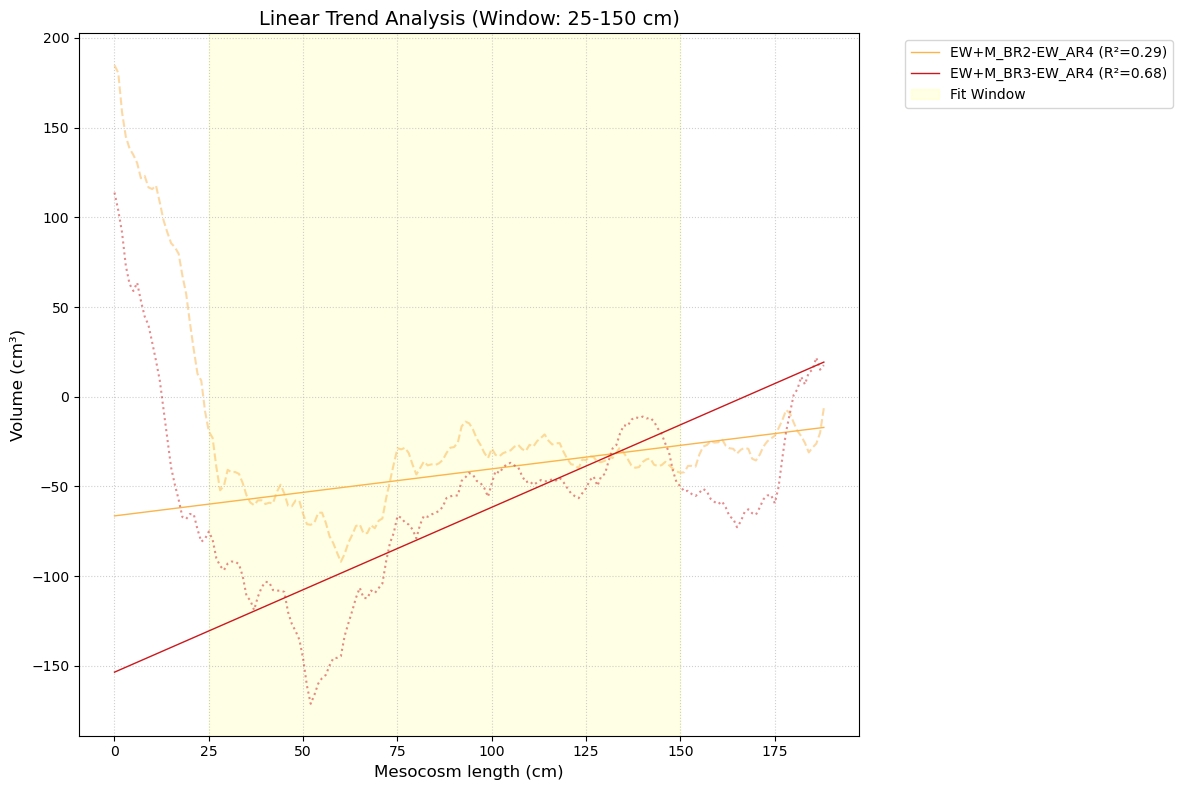

In [28]:
# Animal treatment mapping is already defined above, so we can reuse it here for the linear trend analysis.

animal_treatment_mapping = {

    "DoD_1cm_clip_6fill_align-4_mask_filled": "B_AR3-B_AR2",
    "DoD_1cm_clip_10align-6": "EW_BR1-B_AR3",
    "DoD_1cm_clip_12-10": "EW_BR2- EW_BR1",
    'DoD_1cm_clip_14-10': "EW_BR3-EW_BR1",
    'DoD_1cm_clip_16_masked-10': "EW_BR4-EW_BR1",
    'DoD_1cm_clip_20-17': "EW+M_BR1-EW_AR4",# first mole event minus the DEM from the last EW run 
    'DoD_1cm_clip_22-17': "EW+M_BR2-EW_AR4",
    'DoD_1cm_clip_24-17': "EW+M_BR3-EW_AR4"

}

# 1. SETTINGS: Choose which runs to plot and the window
# Example: Only look at the Bare control and the third Earthworm replicate
RUNS_TO_PLOT = ["EW+M_BR2-EW_AR4",'EW+M_BR3-EW_AR4']  # Adjust as needed "EW1", "EW2", "EW3", 

# Define your fitting window (e.g., ignoring the first and last 10cm)
X_MIN, X_MAX = 25, 150

plt.figure(figsize=(12, 8))

for name, legend_name in animal_treatment_mapping.items():
    # Only process if it's in our "to plot" list
    if legend_name not in RUNS_TO_PLOT:
        continue
        
    if name in surf_data_animal:
        df = surf_data_animal[name]
        
        # Data preparation (Index is our X, vol_net_m3 * 1e6 is our Y)
        x_axis = df.index.values
        y_values = df['vol_net_m3'] * 1e6
        
        # --- STEP 1: APPLY WINDOW MASK ---
        # Filter data for the linear fit based on X_MIN and X_MAX
        mask = (x_axis >= X_MIN) & (x_axis <= X_MAX) & (~np.isnan(y_values))
        
        if np.any(mask):
            # --- STEP 2: FIT LINEAR MODEL ---
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                x_axis[mask], 
                y_values[mask]
            )
            
            # Create the trendline for the FULL length of the data
            line = slope * x_axis + intercept
            
            # --- STEP 3: PLOT RAW DATA AND MODEL ---
            # Plot raw data
            plt.plot(x_axis, y_values, 
                     color=color_mapping[legend_name], 
                     linestyle=linestyle_mapping[legend_name], 
                     alpha=0.5, linewidth=1.5)
            
            # Plot the Linear Model 
            plt.plot(x_axis, line, 
                     color=color_mapping[legend_name], 
                     label=f"{legend_name} (R²={r_value**2:.2f})", 
                     linewidth=1)
            
            print(f"Model for {legend_name}: Slope = {slope:.4f}, Intercept = {intercept:.2f}")

# Visual indicators for the window used
plt.axvspan(X_MIN, X_MAX, color='yellow', alpha=0.1, label="Fit Window")

# Styling
plt.title(f"Linear Trend Analysis (Window: {X_MIN}-{X_MAX} cm)", fontsize=14)
plt.xlabel("Mesocosm length (cm)", fontsize=12)
plt.ylabel("Volume (cm³)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

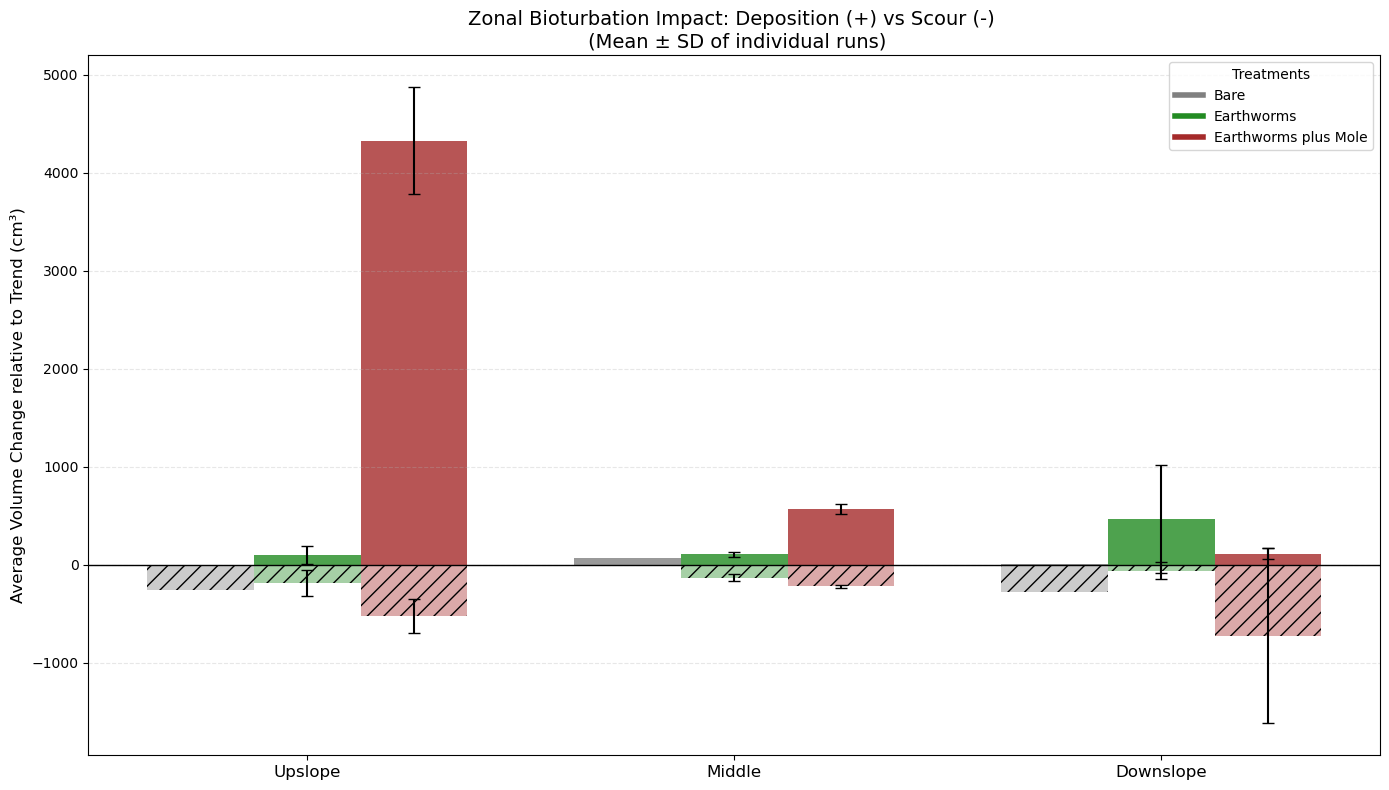

           Treatment      Zone  Above_Mean  Above_Std  Below_Mean  Below_Std
                Bare Downslope    6.352729        NaN  279.950831        NaN
                Bare    Middle   73.367148        NaN   10.361614        NaN
                Bare   Upslope    0.378546        NaN  256.788316        NaN
          Earthworms Downslope  467.980497 546.750492   61.773577  85.390457
          Earthworms    Middle  107.646265  27.546603  130.551208  37.323944
          Earthworms   Upslope   96.182910  92.202674  189.366027 131.707888
Earthworms plus Mole Downslope  112.290343  56.873636  725.399137 893.155235
Earthworms plus Mole    Middle  569.743615  49.560882  218.325950  15.411619
Earthworms plus Mole   Upslope 4328.809560 544.302427  522.782062 177.750098


In [29]:
# 1. Setup Parameters
animal_treatment_mapping = {

    "DoD_1cm_clip_6fill_align-4_mask_filled": "B_AR3-B_AR2",
    "DoD_1cm_clip_10align-6": "EW_BR1-B_AR3",
    "DoD_1cm_clip_12-10": "EW_BR2- EW_BR1",
    'DoD_1cm_clip_14-10': "EW_BR3-EW_BR1",
    'DoD_1cm_clip_16_masked-10': "EW_BR4-EW_BR1",
    'DoD_1cm_clip_20-17': "EW+M_BR1-EW_AR4",# first mole event minus the DEM from the last EW run 
    'DoD_1cm_clip_22-17': "EW+M_BR2-EW_AR4",
    'DoD_1cm_clip_24-17': "EW+M_BR3-EW_AR4"

}

# Get max length across all runs to define unified zones
all_max_x = []
for name in animal_treatment_mapping:
    if name in surf_data_animal:
        all_max_x.append(surf_data_animal[name].index.max())
max_l = max(all_max_x)

zones = {
    "Upslope": (0, max_l/3),# Considering that the max is 189, the upslope part is from 0 to 63
    "Middle": (max_l/3, 2*max_l/3), # this is from 63 to 126
    "Downslope": (2*max_l/3, max_l) # this is from 126 to 189
}

individual_zonal_data = []
labels = {"B": "Bare", "EW": "Earthworms", "EW+M": "Earthworms plus Mole"}
# 2. Process Every Individual Run
for name, legend_name in animal_treatment_mapping.items():
    if name not in surf_data_animal: continue
    
    df = surf_data_animal[name]
    x_axis = df.index.values
    y_raw = df['vol_net_m3'] * 1e6  # Convert to cm3
    
    # Identify treatment category
    if legend_name.startswith("EW+M"): treat_cat = "EW+M"
    elif legend_name.startswith("EW"): treat_cat = "EW"
    else: treat_cat = "B"

    # --- Step A: Fit Model for the Run ---
    
    if treat_cat == "EW+M":
        f_start, f_end = 25, 150
    else:
        f_start, f_end = 25, 150
    
    mask_fit = (x_axis >= f_start) & (x_axis <= f_end) & (~np.isnan(y_raw))
    
    # Safety check: ensure we have data in the window
    if np.sum(mask_fit) > 2:
        res = stats.linregress(x_axis[mask_fit], y_raw[mask_fit])
        y_fit = res.slope * x_axis + res.intercept
        diff = y_raw - y_fit
    else:
        continue # Skip if window is empty

    # --- Step B: Calculate Vol for each Zone ---
    for zone_name, (z_start, z_end) in zones.items():
        z_mask = (x_axis >= z_start) & (x_axis <= z_end) & (~np.isnan(diff))
        if np.sum(z_mask) < 2: continue
        
        x_z = x_axis[z_mask]
        diff_z = diff[z_mask]
        
        vol_above = np.trapz(np.where(diff_z > 0, diff_z, 0), x_z)
        vol_below = np.trapz(np.where(diff_z < 0, np.abs(diff_z), 0), x_z)
        
        individual_zonal_data.append({
            'Run': legend_name,
            'Treatment': labels[treat_cat],
            'Zone': zone_name,
            'Vol_Above': vol_above,
            'Vol_Below': vol_below
        })

# 3. Aggregate Results (Mean and SD)
df_zonal = pd.DataFrame(individual_zonal_data)
summary = df_zonal.groupby(['Treatment', 'Zone']).agg({
    'Vol_Above': ['mean', 'std'],
    'Vol_Below': ['mean', 'std']
}).reset_index()

# Flatten columns: 'Vol_Above_mean', 'Vol_Above_std', etc.
summary.columns = ['Treatment', 'Zone', 'Above_Mean', 'Above_Std', 'Below_Mean', 'Below_Std']

# 4. Visualization: Grouped Bar Chart with Error Bars
fig, ax = plt.subplots(figsize=(14, 8))

treatments_list = ["Bare", "Earthworms", "Earthworms plus Mole"]
zone_list = ["Upslope", "Middle", "Downslope"]
colors_map = {"Bare": "gray", "Earthworms": "forestgreen", "Earthworms plus Mole": "brown"}

x = np.arange(len(zone_list))
width = 0.25  # Width of each bar group

for i, treat in enumerate(treatments_list):
    # Filter data for this treatment
    t_data = summary[summary['Treatment'] == treat].set_index('Zone').reindex(zone_list)
    
    offset = (i - 1) * width
    
    # Plot Positive Volume (Above)
    ax.bar(x + offset, t_data['Above_Mean'], width, yerr=t_data['Above_Std'],
           label=f"{treat} (Deposition)", color=colors_map[treat], alpha=0.8, capsize=4)
    
    # Plot Negative Volume (Below) - shown as negative bars for clarity
    ax.bar(x + offset, -t_data['Below_Mean'], width, yerr=t_data['Below_Std'],
           color=colors_map[treat], alpha=0.4, hatch='//', capsize=4)

# Styling
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(zone_list, fontsize=12)
ax.set_ylabel("Average Volume Change relative to Trend (cm³)", fontsize=12)
ax.set_title("Zonal Bioturbation Impact: Deposition (+) vs Scour (-) \n (Mean ± SD of individual runs)", fontsize=14)

# Custom legend to simplify
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=colors_map[t], lw=4, label=t) for t in treatments_list]
ax.legend(handles=legend_elements, title="Treatments", loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Display the numerical table for your records
print(summary.to_string(index=False))

### Plot vol averages

Now, I want to plot the average volume change, averaging the three replicats of each treatment

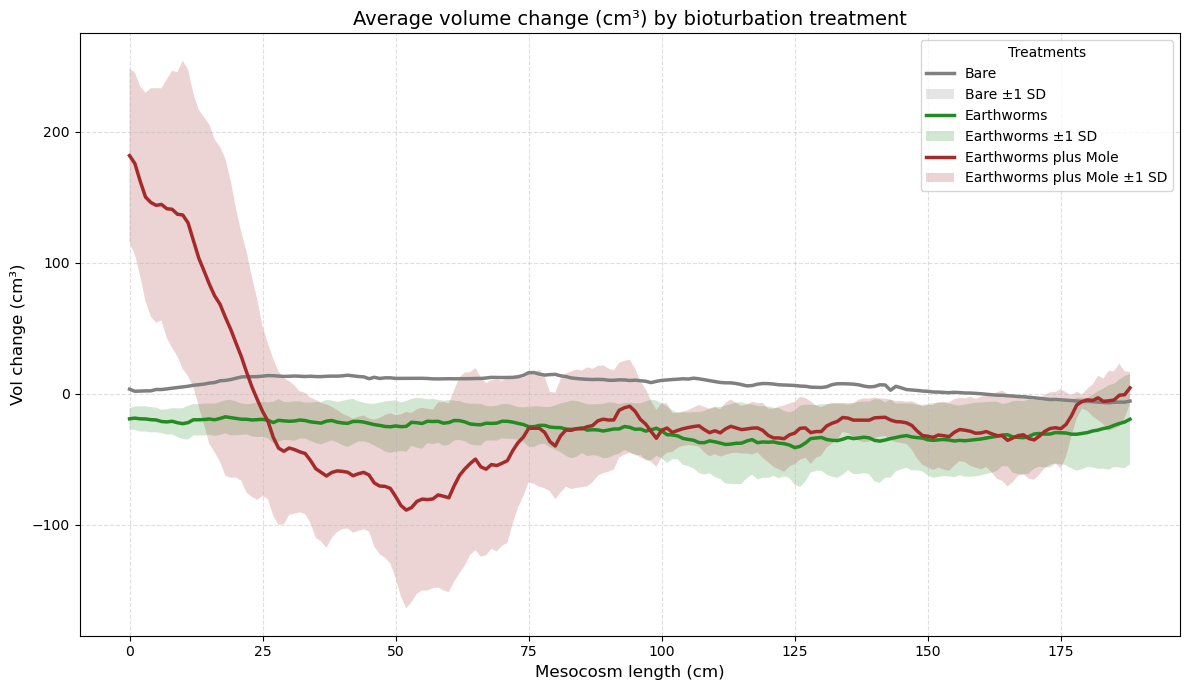

In [30]:
# 1. Setup grouping containers
treatment_groups = {'B': [], 'EW': [], 'EW+M': []}


# 2. Collect and group the data
for name, legend_name in animal_treatment_mapping.items():

    if name not in surf_data_animal:
        print(f"Warning: {name} not found")
        continue

    df = surf_data_animal[name]

    if 'vol_net_m3' not in df.columns:
        print(f"Warning: 'vol_net_m3' not found in {name}")
        continue

    # Convert to cm3
    series = df['vol_net_m3'] * 1e6

    # Identify treatment category
    if legend_name.startswith("EW+M"): treat_cat = "EW+M"
    elif legend_name.startswith("EW"): treat_cat = "EW"
    else: treat_cat = "B"

    treatment_groups[treat_cat].append(series) # Group the series by treatment category


# 3. Plotting
plt.figure(figsize=(12, 7))

colors = {"B": "gray", "EW": "forestgreen", "EW+M": "brown"}
labels = {"B": "Bare", "EW": "Earthworms", "EW+M": "Earthworms plus Mole"}

for treat, series_list in treatment_groups.items():

    if not series_list:
        continue

    combined_df = pd.concat(series_list, axis=1)

    avg_line = combined_df.mean(axis=1)
    std_dev = combined_df.std(axis=1)
    x_axis = combined_df.index

    plt.plot(x_axis,
             avg_line,
             label=labels[treat],
             color=colors[treat],
             linewidth=2.5)

    plt.fill_between(x_axis,
                     avg_line - std_dev,
                     avg_line + std_dev,
                     color=colors[treat],
                     alpha=0.2,
                     edgecolor='none',
                     label=f"{labels[treat]} ±1 SD")


plt.title("Average volume change (cm³) by bioturbation treatment", fontsize=14)
plt.xlabel("Mesocosm length (cm)", fontsize=12)
plt.ylabel("Vol change (cm³)", fontsize=12)
#plt.axhline(0, color='black', linewidth=1)
plt.legend(title="Treatments", loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


This graph is very useful, as it indicates how much the volume changed along the slope after animal treatment. Owever, in this graph the soil compaction and subsidence related to the rainfall events is quite visible. For this reason, although the pattern might be correct, the data can be biased.


In the previous analysis, I subtracted to all the DEM the same initial condition (meaning the DEM after the last rainfall event with bare soil). However, in this way the compaction created after the rain is taken too much into account, and it is not possible to identify the real animal effect. For this reason, the ideal situation is:
- isolate the baseline of each treatment:
    - In the case of the ew, if I want to know the very beginning soil change, the baseline is the DEM after the last rain with bare soil (chunk 6) . This only for the first EW treatment. For the rest, the baseline is the before rain of the first treatment (chunk 10).
    - For the mole, the baseline is the after rainfall event of last ew run (chunk 17). This is the baseline for all the others mole DEMs
- Choose if using the detrended or not: detrending is taking out the slope from all the events. in my case, the detrend can be used to reduce the compaction due to rainfall events, but keeping the mounds-collapse patterns.
 

#### Try to fit a linear model and then plot again the data using the same linear model as baseline to see the positive and negative changes

The aim of the following code is to see the subsidence, and calculate the volume. In the following code, I try to fit the model to the window only for the mole treatment, the other I fit them over the whole length. This because the Mole creates large changes outside that window. 
Better written: The Mole treatment exhibited significant edge-effect artifacts between 0-25cm and 175-200cm due to burrowing behavior near the mesh, whereas Bare and Earthworm treatments remained representative across the full profile.

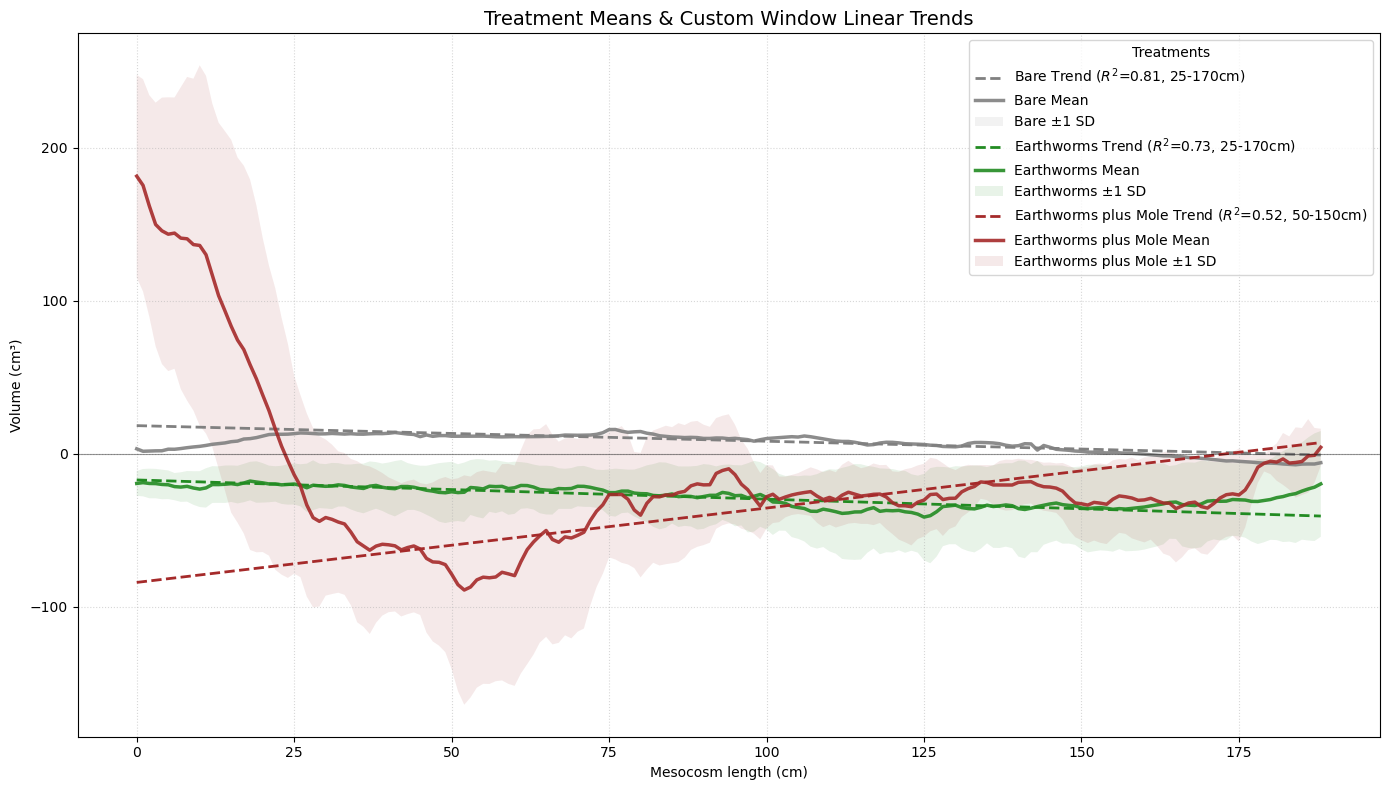

              Treatment    Slope  R-Squared  Area_Above  Area_Below
0                  Bare -0.10198      0.813      128.12      485.40
1            Earthworms -0.12547      0.727      381.92      220.34
2  Earthworms plus Mole  0.48603      0.520     5238.20     1369.55


In [32]:
plt.figure(figsize=(14, 8))
summary_stats = []

# Using the same labels and colors defined previously
colors = {"B": "gray", "EW": "forestgreen", "EW+M": "brown"}
labels = {"B": "Bare", "EW": "Earthworms", "EW+M": "Earthworms plus Mole"}

for treat, series_list in treatment_groups.items():# animal_treatment_mapping
    if not series_list: continue
    
    combined_df = pd.concat(series_list, axis=1)
    avg_line = combined_df.mean(axis=1)
    std_dev = combined_df.std(axis=1)
    x_axis = combined_df.index.values
    
    # --- STEP 1: DEFINE SPECIFIC WINDOWS ---
    if treat == 'EW+M':
        fit_start, fit_end = 50, 150
        window_label = "50-150cm"
    else:
        fit_start, fit_end = 25, 170
        window_label = "25-170cm"
    
    # Create mask for the chosen window
    mask_subset = (x_axis >= fit_start) & (x_axis <= fit_end) & (~np.isnan(avg_line))
    
    # --- STEP 2: FIT MODEL ---
    res = stats.linregress(x_axis[mask_subset], avg_line[mask_subset])
    
    # --- STEP 3: PROJECT & CALCULATE AREAS ---
    full_y_fit = res.slope * x_axis + res.intercept
    diff = avg_line - full_y_fit
    valid_mask = ~np.isnan(diff)
    
    x_v = x_axis[valid_mask]
    diff_v = diff[valid_mask]
    
    # Area Above/Below the trendline
    area_above = np.trapz(np.where(diff_v > 0, diff_v, 0), x_v)
    area_below = np.trapz(np.where(diff_v < 0, np.abs(diff_v), 0), x_v)

    summary_stats.append({
        'Treatment': labels[treat],
        #'Fit_Window': window_label,
        'Slope': round(res.slope, 5),
        'R-Squared': round(res.rvalue**2, 3),
        'Area_Above': round(area_above, 2),
        'Area_Below': round(area_below, 2)
    })

    # --- STEP 4: PLOTTING ---
    # Plot Trend Line (Extrapolated)
    #plt.plot(x_axis, full_y_fit, color=colors[treat], linewidth=2, linestyle='--',
    #         label=f"{labels[treat]} Trend ({window_label})")
    # Plot Trend Line (Extrapolated)
# Using :.3f formats it to 3 decimal places
    plt.plot(x_axis, full_y_fit, color=colors[treat], linewidth=2, linestyle='--',
         label=f"{labels[treat]} Trend ($R^2$={res.rvalue**2:.2f}, {window_label})")
    
    # Plot Mean Line
    plt.plot(x_axis, avg_line, color=colors[treat], alpha=0.9, linewidth=2.5, 
             label=f"{labels[treat]} Mean")

    # Plot the standard deviation shade
    plt.fill_between(x_axis, avg_line - std_dev, avg_line + std_dev,
                     color=colors[treat], alpha=0.1, edgecolor='none', label=f"{labels[treat]} ±1 SD")

# Formatting
plt.axhline(0, color='black', linewidth=0.8, alpha=0.4)
plt.title("Treatment Means & Custom Window Linear Trends", fontsize=14)
plt.xlabel("Mesocosm length (cm)")
plt.ylabel("Volume (cm³)")
plt.legend( title="Treatments", loc='upper right')#bbox_to_anchor=(1.05, 1),
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(pd.DataFrame(summary_stats))

Calculate the percentage of difference in slope between bare, earthworms and mole treatment

In [33]:
# 1. First, we need the Bare Model as the Baseline
bare_series = pd.concat(treatment_groups['B'], axis=1).mean(axis=1)
x_bare = bare_series.index.values
res_bare = stats.linregress(x_bare[~np.isnan(bare_series)], bare_series[~np.isnan(bare_series)])

# 2. Define Segments (Adjust bounds based on your total length)
max_l = x_bare.max()
segments = {
    'Upslope':  (0, max_l/3),
    'Middle': (max_l/3, 2*max_l/3),
    'Downslope':  (2*max_l/3, max_l)
}

comparison_data = []

for treat, series_list in treatment_groups.items():
    if treat == 'B' or not series_list: continue # Skip Bare (it's the baseline)
    
    combined_df = pd.concat(series_list, axis=1)
    avg_line = combined_df.mean(axis=1)
    x_axis = combined_df.index.values
    
    # Fit Model for treatment (using your specific window for M)
    if treat == 'M':
        fit_start, fit_end = 50, 150
        window_label = "50-150cm"
    else:
        fit_start, fit_end = 25, 170
        window_label = "25-170cm"
    mask = (x_axis >= f_start) & (x_axis <= f_end) & (~np.isnan(avg_line))
    res_treat = stats.linregress(x_axis[mask], avg_line[mask])
    
    row = {'Comparison': f'{treat} vs Bare'}
    
    for seg_name, (start, end) in segments.items():
        midpoint = (start + end) / 2
        
        # Predicted value from Linear Models
        y_bare = res_bare.slope * midpoint + res_bare.intercept
        y_treat = res_treat.slope * midpoint + res_treat.intercept
        
        # Percentage Vertical Change relative to Bare in absolute values
        # Formula: |(Treat - Bare) / abs(Bare)| * 100
        if y_bare != 0:
            abs_pct_diff = abs((y_treat - y_bare) / abs(y_bare)) * 100
        else:
            abs_pct_diff = 0 # Avoid division by zero, can also set to None or a specific value
        
        row[seg_name] = f"{abs_pct_diff:.2f}%"
        
    comparison_data.append(row)

# Create and display the table
results_table = pd.DataFrame(comparison_data)
print("Magnitude of Difference (|%|) Relative to Bare Baseline:")
print(results_table.to_string(index=False))

Magnitude of Difference (|%|) Relative to Bare Baseline:
  Comparison Upslope  Middle Downslope
  EW vs Bare 266.24% 520.60%  1976.17%
EW+M vs Bare 600.46% 620.77%   736.99%


#### Plot the positive and negative values of soil excavated/moved after animals

In the code to fit the linear model, we calculated the volume above and below the linear model. This method shows the general morphology or net slope change of a treatment, but not the actual average magnitude of activity.

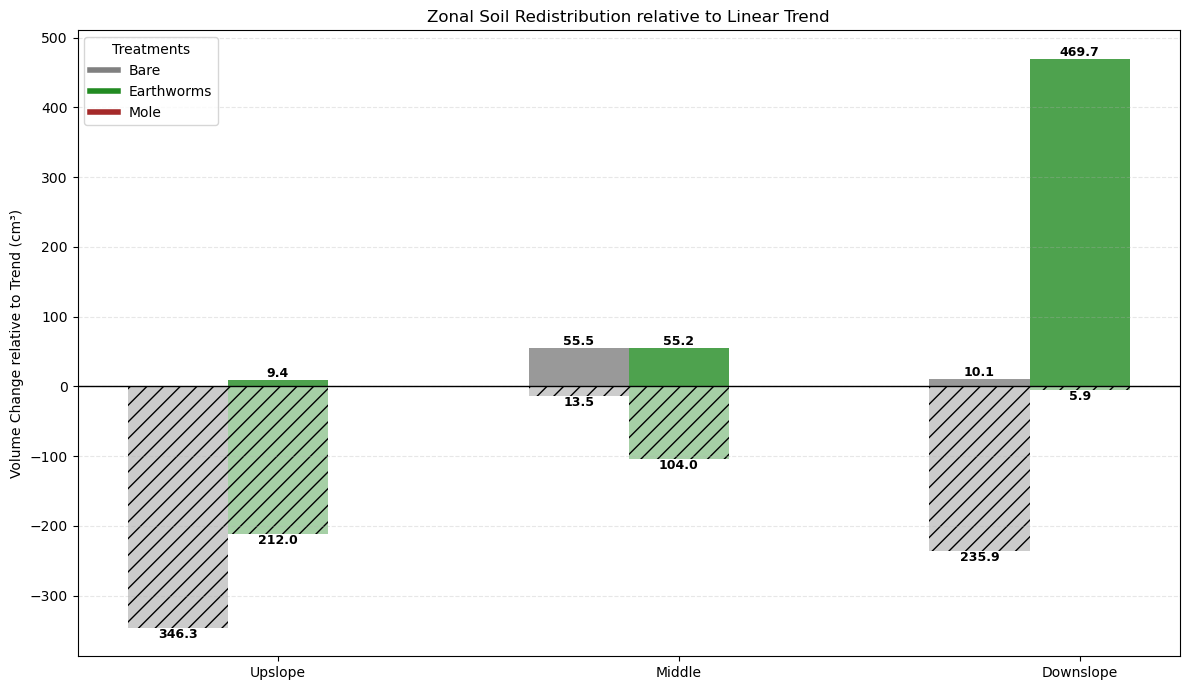

In [ ]:
# 1. Define Zone Boundaries
max_l = max([df.index.max() for series_list in treatment_groups.values() for df in series_list])
zones = {
    "Upslope": (0, max_l/3),
    "Middle": (max_l/3, 2*max_l/3),
    "Downslope": (2*max_l/3, max_l)
}

zonal_volumes = []

for treat, series_list in treatment_groups.items():
    if not series_list: continue
    
    combined_df = pd.concat(series_list, axis=1)
    avg_line = combined_df.mean(axis=1)
    x_axis = combined_df.index.values
    
    # --- FIT MODEL (using 50,150 for M, 25-170 for others) ---
    f_start, f_end = (25, 170) if treat == 'M' else (50, 150)
    mask_fit = (x_axis >= f_start) & (x_axis <= f_end) & (~np.isnan(avg_line))
    res = stats.linregress(x_axis[mask_fit], avg_line[mask_fit])
    
    # Project model and find differences
    full_y_fit = res.slope * x_axis + res.intercept
    diff = avg_line - full_y_fit

    for zone_name, (z_start, z_end) in zones.items():
        z_mask = (x_axis >= z_start) & (x_axis <= z_end) & (~np.isnan(diff))
        if np.sum(z_mask) < 2: continue

        x_z = x_axis[z_mask]
        diff_z = diff[z_mask]
        
        # Calculate Zonal Above (Positive) and Below (Negative)
        vol_above = np.trapz(np.where(diff_z > 0, diff_z, 0), x_z)# or trapezoid if NumPy 2.x
        vol_below = np.trapz(np.where(diff_z < 0, np.abs(diff_z), 0), x_z)
        
        zonal_volumes.append({
            'Treatment': labels[treat],
            'Zone': zone_name,
            'Vol_Above': vol_above,
            'Vol_Below': -vol_below  # Negative for plotting downward
        })

df_zones = pd.DataFrame(zonal_volumes)

# --- 2. PLOTTING ---
fig, ax = plt.subplots(figsize=(12, 7))

treat_order = ["Bare", "Earthworms", "Mole"]
zone_names = ["Upslope", "Middle", "Downslope"]
colors_map = {"Bare": "gray", "Earthworms": "forestgreen", "Mole": "brown"}
bar_width = 0.25
x_pos = np.arange(len(zone_names))

for i, treat in enumerate(treat_order):
    subset = df_zones[df_zones['Treatment'] == treat].set_index('Zone').reindex(zone_names)
    offset = (i - 1) * bar_width
    
    # Plot Vol Above (Deposition)
    ax.bar(x_pos + offset, subset['Vol_Above'], width=bar_width, 
           color=colors_map[treat], alpha=0.8)
    
    # Plot Vol Below (Erosion/Collapse)
    ax.bar(x_pos + offset, subset['Vol_Below'], width=bar_width, 
           color=colors_map[treat], alpha=0.4, hatch='//')
    # --- ADD MEAN LABELS ---
    for j, zone in enumerate(zone_names):
        # Label for Above bars
        val_above = subset.loc[zone, 'Vol_Above']
        if not np.isnan(val_above) and val_above != 0:
            ax.text(j + offset, val_above, f'{val_above:.1f}', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
            
        # Label for Below bars
        val_below = subset.loc[zone, 'Vol_Below']
        if not np.isnan(val_below) and val_below != 0:
            # We use va='top' because the bars go downwards (negative)
            ax.text(j + offset, val_below, f'{abs(val_below):.1f}', 
                    ha='center', va='top', fontsize=9, fontweight='bold')

# Formatting
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x_pos)
ax.set_xticklabels(zone_names)
ax.set_ylabel("Volume Change relative to Trend (cm³)")
ax.set_title("Zonal Soil Redistribution relative to Linear Trend")

# Custom Legend
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color=colors_map[t], lw=4, label=t) for t in treat_order]
ax.legend(handles=custom_lines, title="Treatments", loc='best')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Export the values of means 

Export a csv file with the difference among the average of the three treatments. Once I export it, I can check where is the average change among them and define the compaction value

In [36]:
# 5. Store and export mean values
mean_profiles = {}

for treat, series_list in treatment_groups.items():

    if not series_list:
        continue

    combined_df = pd.concat(series_list, axis=1)
    avg_line = combined_df.mean(axis=1).round(3)  # Round to 3 decimals for cleaner output

    mean_profiles[treat] = avg_line

# Combine into a single DataFrame
mean_df = pd.DataFrame(mean_profiles)

# Optional: Rename columns to match legend labels
mean_df.rename(columns=labels, inplace=True)

# Print to console
print("\nMean volume change (cm³) per treatment:\n")
print(mean_df)

# Export to CSV
#mean_df.to_csv("mean_volume_change_by_treatment.csv")

#print("\nCSV file saved as: mean_volume_change_by_treatment.csv")


Mean volume change (cm³) per treatment:

      Bare  Earthworms  Earthworms plus Mole
0    3.367     -19.248               181.566
1    1.761     -18.733               175.570
2    1.928     -19.270               162.089
3    2.053     -19.355               149.986
4    2.096     -19.906               145.853
..     ...         ...                   ...
184 -7.056     -25.923                -5.550
185 -6.606     -24.249                -4.904
186 -6.530     -22.866                -1.248
187 -6.548     -21.697                -0.871
188 -5.720     -19.559                 4.374

[189 rows x 3 columns]


# Account for subsidence

Fir a linear model

In [ ]:
# Import the detrended from the slope DEM data. Import them as folder
folder_path1_c = pathlib.Path("C:\\DEM_1cm_detrend_surface_rows_z")


In [ ]:
# Create a dictionary
# Dictionary to store dataframes: { 'filename': dataframe } 
detrend_dem_data = {}
# Loop through all CSVs in the folder
for file in folder_path1_c.glob("*.csv"):
    # Read the CSV and store it with the filename as the key
    detrend_dem_data[file.stem] = pd.read_csv(file)
print(f"Successfully loaded {len(detrend_dem_data)} detrended DEM files.")


In [ ]:
# Create a mapping dictionary for the detrended DEMs
detrended_dem_mapping = {
    '1cm_Detrended_clip_3fill' : 'B1_BR',
    '1cm_Detrended_clip4_masked': 'B1_AR',
    '1cm_Detrended_clip_5fill-align': 'B2_BR',
    '1cm_Detrended_clip_6fill_align': 'B2_AR',
    '1cm_Detrended_clip_10align': 'EW1_BR',
    '1cm_Detrended_clip_11': 'EW1_AR',
    '1cm_Detrended_clip_12': 'EW2_BR',
    '1cm_Detrended_clip_13': 'EW2_AR',
    '1cm_Detrended_clip_14': 'EW3_BR',
    '1cm_Detrended_clip_15': 'EW3_AR',
    '1cm_Detrended_clip_16_masked': 'EW4_BR',
    '1cm_Detrended_clip_17': 'EW4_AR',
    '1cm_Detrended_clip_20': 'M1_BR',
    '1cm_Detrended_clip_21': 'M1_AR',
    '1cm_Detrended_clip_22': 'M2_BR',
    '1cm_Detrended_clip_23': 'M2_AR',
    '1cm_Detrended_clip_24': 'M3_BR',
    '1cm_Detrended_clip_25': 'M3_AR'
}


Plot all elevation together

In [ ]:
plt.figure(figsize=(12, 7))
# To iterate along the data that are in the dictionary and plot only those that I want, I will use the mapping dictionary to check if the name of the file is in the dictionary and then plot it with the name I want in the legend.
for name, legend_name in detrended_dem_mapping.items():
    
    # Check if that file exists in your dictionary
    if name in detrend_dem_data:
        df = detrend_dem_data[name]
        
        if 'mean_surf_change_row (m)' in df.columns:
            plt.plot(
                df['mean_surf_change_row (m)'] * 100,
                label=legend_name,
                linewidth=2,
                color=np.random.rand(3,)
            )
        else:
            print(f"Warning: Column not found in {name}")
    else:
        print(f"Warning: {name} not found in detrend_dem_data")

plt.title("Mean elevation (cm) along slope", fontsize=14)
plt.xlabel("Mesocosm length (cm)", fontsize=12)
plt.ylabel("Mean elevation (cm)", fontsize=12)

plt.legend(title="Dems", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Setup grouping containers

detr_treatment_groups = {
    'B': [],
    'EW': [],
    'M': []
}

# 2. Collect and group the data
for name, df in detrend_dem_data.items():
    run = detrended_dem_mapping.get(name)
    
    if run and 'mean_surf_change_row (m)' in df.columns:
        
        # Extract treatment letters only (B, EW, M)
        treatment = re.match(r"[A-Za-z]+", run).group()
        
        series = df['mean_surf_change_row (m)'] * 100
        detr_treatment_groups[treatment].append(series)
        
    else:
        print(f"Skipping or Warning: {name}")


# 3. Plotting


colors = {"B": "lightgray", "EW": "forestgreen", "M": "brown"}
labels = {"B": "Bare", "EW": "Earthworms", "M": "Mole"}

mean_table = pd.DataFrame()

plt.figure(figsize=(12, 7))

for treat, series_list in detr_treatment_groups.items():
    if not series_list:
        continue
    
    # Combine list of series into a single DataFrame to calculate mean/std row-wise
    combined_df = pd.concat(series_list, axis=1)

    
    avg_line = combined_df.mean(axis=1)
    std_dev = combined_df.std(axis=1)
    x_axis = combined_df.index # Assuming index represents mesocosm length
    # ---- STORE MEAN IN TABLE ----
    mean_table[treat] = avg_line.round(3)  # Round to 3 decimals for cleaner output

    # Plot the Mean Line
    plt.plot(x_axis, avg_line, label=labels[treat], color=colors[treat], linewidth=2.5)

    # Plot the Variance Shade (Mean +/- 1 Standard Deviation)
    plt.fill_between(x_axis, 
                     avg_line - std_dev, 
                     avg_line + std_dev, 
                     color=colors[treat], 
                     alpha=0.2, 
                     edgecolor='none')
# 4. Styling
plt.title("Average height by treatment", fontsize=14)
plt.xlabel("Mesocosm length (cm)", fontsize=12)
plt.ylabel("Average height (cm)", fontsize=12)
#plt.axhline(0, color='black', linewidth=1, linestyle='-') # Reference line at 0
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()  

In [ ]:
# 2. Plotting & Modeling
colors = {"B": "lightgray", "EW": "forestgreen", "M": "brown"}
labels = {"B": "Bare", "EW": "Earthworms", "M": "Mole"}

plt.figure(figsize=(12, 8))

# Dictionary to store model parameters for reporting
model_results1 = []

for treat, series_list in detr_treatment_groups.items():
    if not series_list:
        continue
    
    combined_df = pd.concat(series_list, axis=1)
    avg_line = combined_df.mean(axis=1)
    std_dev = combined_df.std(axis=1)
    x_axis = combined_df.index  # Mesocosm length

    # --- LINEAR REGRESSION CALCULATION ---
    # Handle NaNs if any exist in your DEM data
    mask = ~np.isnan(avg_line)
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_axis[mask], avg_line[mask])
    
    # Create the trendline based on the model: y = mx + b
    line_fit = slope * x_axis + intercept
    
    # Store results for analysis
    model_results1.append({
        'Treatment': labels[treat],
        'Slope (cm/cm)': round(slope, 4),
        'Intercept': round(intercept, 3),
        'R-Squared': round(r_value**2, 3),
        'P-Value': round(p_value, 4)
    })

    # --- PLOTTING ---
    # 1. Plot the Variance Shade
    plt.fill_between(x_axis, avg_line - std_dev, avg_line + std_dev, 
                     color=colors[treat], alpha=0.15, edgecolor='none')

    # 2. Plot the Raw Average Line (dashed or thin)
    plt.plot(x_axis, avg_line, color=colors[treat], alpha=0.4, linestyle='--', label=f"{labels[treat]} (Raw)")

    # 3. Plot the Linear Fit (Solid and Bold)
    plt.plot(x_axis, line_fit, color=colors[treat], linewidth=3, 
             label=f"{labels[treat]} Fit (R²={r_value**2:.2f})")

# 4. Styling & Output
plt.title("Linear Trends of Soil Surface Change by Treatment", fontsize=14)
plt.xlabel("Mesocosm length (cm)", fontsize=12)
plt.ylabel("Average height change (cm)", fontsize=12)
#plt.axhline(0, color='black', linewidth=1, alpha=0.5) 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Display the statistical summary
stats_df = pd.DataFrame(model_results1)
print("--- Linear Model Summary ---")
print(stats_df)

Add now the 95% confidence interval (CI). To do this, I calculate the standard error of the estimate ($SE$) and use the $t$-distribution to find the interval boundaries.

In [ ]:
# 3. Plotting & Modeling
colors = {"B": "lightgray", "EW": "forestgreen", "M": "brown"}
labels = {"B": "Bare", "EW": "Earthworms", "M": "Mole"}

plt.figure(figsize=(12, 8))

# Create a dictionary to store model parameters for reporting

# Here calculate the 95% confidence intervals for the linear regression of each treatment and plot them as shaded areas around the trend line

for treat, series_list in detr_treatment_groups.items():
    if not series_list: continue
    
    combined_df = pd.concat(series_list, axis=1)
    avg_line = combined_df.mean(axis=1)
    x_axis = combined_df.index.values
    
    # 1. Clean data for regression (remove NaNs)
    mask = ~np.isnan(avg_line)
    x_clean = x_axis[mask]
    y_clean = avg_line[mask]
    n = len(x_clean)

    # 2. Perform Linear Regression
    res = stats.linregress(x_clean, y_clean)
    y_fit = res.slope * x_clean + res.intercept

    # 3. Calculate 95% Confidence Interval for the Trend Line
    # Standard Error of the estimate
    y_err = y_clean - y_fit
    s_err = np.sqrt(np.sum(y_err**2) / (n - 2)) 
    
    # Calculate CI range across the x-axis
    t_val = stats.t.ppf(0.975, n - 2) # t-statistic for 95%
    ci = t_val * s_err * np.sqrt(1/n + (x_clean - np.mean(x_clean))**2 / np.sum((x_clean - np.mean(x_clean))**2))

   

    # 4. PLOTTING
    # Plot the 95% CI Shade (Uncertainty of the trend)
    plt.fill_between(x_clean, y_fit - ci, y_fit + ci, 
                     color=colors[treat], alpha=0.5, label=f"{labels[treat]} 95% CI")

    # Plot the Linear Fit Line
    plt.plot(x_clean, y_fit, color=colors[treat], linewidth=2.5, 
             label=f"{labels[treat]} Fit (Slope: {res.slope:.4f})")

    # Optional: Plot the raw average as a faint line to see the "noise"
    plt.plot(x_clean, y_clean, color=colors[treat], alpha=0.7, linestyle=':')

# 5. Styling
plt.title("Linear Regression of Surface Change with 95% Confidence Intervals", fontsize=14)
plt.xlabel("Mesocosm length (cm)", fontsize=12)
plt.ylabel("Height Change (cm)", fontsize=12)
#plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Display the statistical summary
stats_df = pd.DataFrame(model_results)# it is the same model results than before
print("--- Linear Model Summary ---")
print(stats_df)

As there could be boundaries effect, I want to try to fit the linear model considering the area where the changes are more stables, emaning from 100 to 175 cm of the mesocosm length. 

In [ ]:
# 1. Settings
START_CM, END_CM = 25,175 #100, 175
colors = {"B": "lightgray", "EW": "forestgreen", "M": "brown"}
labels = {"B": "Bare", "EW": "Earthworms", "M": "Mole"}

plt.figure(figsize=(14, 8))
summary_stats = []

for treat, series_list in detr_treatment_groups.items():
    if not series_list: continue
    
    combined_df = pd.concat(series_list, axis=1)
    avg_line = combined_df.mean(axis=1)
    x_axis = combined_df.index.values
    
    # --- STEP 1: Fit Model on SUBSET ---

    
    # Create mask for the chosen window



    mask_subset = (x_axis >= START_CM) & (x_axis <= END_CM) & (~np.isnan(avg_line))
    res = stats.linregress(x_axis[mask_subset], avg_line[mask_subset])
    
    # --- STEP 2: Project Model & Calculate Difference ---
    full_y_fit = res.slope * x_axis + res.intercept
    diff = avg_line - full_y_fit
    
    # --- STEP 3: Handle NaNs for Integration ---
    # We create a mask for the entire profile where data exists
    valid_mask = ~np.isnan(diff)
    x_valid = x_axis[valid_mask]
    diff_valid = diff[valid_mask]
    
    # Area Above Model (Positive residuals)
    area_above = np.trapz(np.where(diff_valid > 0, diff_valid, 0), x_valid)
    
    # Area Below Model (Negative residuals - converted to absolute for volume)
    area_below = np.trapz(np.where(diff_valid < 0, np.abs(diff_valid), 0), x_valid)

    # Calculate the 95% confidence intervals for the linear regression of each treatment and plot them as shaded areas around the trend line
    
    n = len(x_valid)
    y_err = avg_line[valid_mask] - full_y_fit[valid_mask]
    s_err = np.sqrt(np.sum(y_err**2) / (n - 2))
    t_val = stats.t.ppf(0.975, n - 2)
    ci = t_val * s_err * np.sqrt(1/n + (x_valid - np.mean(x_valid))**2 / np.sum((x_valid - np.mean(x_valid))**2))


    summary_stats.append({
        'Treatment': labels[treat],
        'Slope': round(res.slope, 5),
        'Intercept': round(res.intercept, 3),
        'R-Squared': round(res.rvalue**2, 3),
        'P-Value': round(res.pvalue, 4),
        'Area_Above_cm2': round(area_above, 2),
        'Area_Below_cm2': round(area_below, 2),
        'Net_Balance_cm2': round(area_above - area_below, 2)
    })

    # --- STEP 4: Plotting ---
    #Plot the 95% CI Shade (Uncertainty of the trend)
    plt.fill_between(x_valid, full_y_fit[valid_mask] - ci, full_y_fit[valid_mask] + ci,
                        color=colors[treat], alpha=0.3, label=f"{labels[treat]} 95% CI")
                         
    plt.plot(x_axis, avg_line, color=colors[treat], alpha=0.3)
    plt.plot(x_axis, full_y_fit, color=colors[treat], linewidth=2.5, linestyle='--',
             label=f"{labels[treat]} Trend (Slope: {res.slope:.4f})")
    
    # Optional: Fill the areas to visualize the "Above/Below"
    plt.fill_between(x_valid, full_y_fit[valid_mask], avg_line[valid_mask], 
                     where=(avg_line[valid_mask] > full_y_fit[valid_mask]),
                     color=colors[treat], alpha=0.1)

# Formatting
plt.axvspan(START_CM, END_CM, color='y', alpha=0.05, label="Fit Window")
plt.title(f"Profile Deviation from Linear Trend ({START_CM}-{175}cm Window)")
plt.xlabel("Length (cm)")
plt.ylabel("Height (cm)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Display Results Table
stats_df = pd.DataFrame(summary_stats)
print(stats_df)

Use different windows to calculate the linear model, depending on the treatment

In [ ]:
# 1. Settings

colors = {"B": "lightgray", "EW": "forestgreen", "M": "brown"}
labels = {"B": "Bare", "EW": "Earthworms", "M": "Mole"}

plt.figure(figsize=(14, 8))
summary_stats = []

for treat, series_list in detr_treatment_groups.items():
    if not series_list: continue
    
    combined_df = pd.concat(series_list, axis=1)
    avg_line = combined_df.mean(axis=1)
    x_axis = combined_df.index.values
    
    # --- STEP 1: Fit Model on SUBSET ---
        #  DEFINE TREATMENT-SPECIFIC WINDOWS ---
    if treat == 'M':
        # Apply the window for Mole treatment
        fit_start, fit_end = 25, 175
        window_label = "25-175cm"
    else:
        # Use full length for Bare and Earthworms
        fit_start, fit_end = x_axis.min(), x_axis.max()
        window_label = "Full Profile"
    
 
    # Create mask for the chosen window
    mask_subset = (x_axis >= fit_start) & (x_axis <= fit_end) & (~np.isnan(avg_line))
    res = stats.linregress(x_axis[mask_subset], avg_line[mask_subset])
    
    # --- STEP 2: Project Model & Calculate Difference ---

    full_y_fit = res.slope * x_axis + res.intercept
    diff = avg_line - full_y_fit
    valid_mask = ~np.isnan(diff)
    
    x_v = x_axis[valid_mask]
    y_v = avg_line[valid_mask]
    fit_v = full_y_fit[valid_mask]
    
    # Area Above/Below
    area_above = np.trapz(np.where(diff[valid_mask] > 0, diff[valid_mask], 0), x_v)
    area_below = np.trapz(np.where(diff[valid_mask] < 0, np.abs(diff[valid_mask]), 0), x_v)

    # Calculate the 95% confidence intervals for the linear regression of each treatment and plot them as shaded areas around the trend line
    
    n = len(x_valid)
    y_err = avg_line[valid_mask] - full_y_fit[valid_mask]
    s_err = np.sqrt(np.sum(y_err**2) / (n - 2))
    t_val = stats.t.ppf(0.975, n - 2)
    ci = t_val * s_err * np.sqrt(1/n + (x_valid - np.mean(x_valid))**2 / np.sum((x_valid - np.mean(x_valid))**2))


    summary_stats.append({
        'Treatment': labels[treat],
        'Slope': round(res.slope, 5),
        'Intercept': round(res.intercept, 3),
        'R-Squared': round(res.rvalue**2, 3),
        'P-Value': round(res.pvalue, 4),
        'Area_Above_cm2': round(area_above, 2),
        'Area_Below_cm2': round(area_below, 2),
        'Net_Balance_cm2': round(area_above - area_below, 2),
        'Fit_Window': window_label
    })

    # --- STEP 4: Plotting ---
    #Plot the 95% CI Shade (Uncertainty of the trend)
    plt.fill_between(x_valid, full_y_fit[valid_mask] - ci, full_y_fit[valid_mask] + ci,
                        color=colors[treat], alpha=0.3, label=f"{labels[treat]} 95% CI")
                         
    plt.plot(x_axis, avg_line, color=colors[treat], alpha=0.3)

    # Plot Trend Line (Extrapolated to full length regardless of fit window)
    plt.plot(x_axis, full_y_fit, color=colors[treat], linewidth=2.5, linestyle='--',
             label=f"{labels[treat]} Trend ({window_label})")
    
    # Optional: Fill the areas to visualize the "Above/Below"
    plt.fill_between(x_valid, full_y_fit[valid_mask], avg_line[valid_mask], 
                     where=(avg_line[valid_mask] > full_y_fit[valid_mask]),
                     color=colors[treat], alpha=0.1)

# Formatting
#plt.axvspan(START_CM, END_CM, color='y', alpha=0.05, label="Fit Window")
plt.title(f"Profile Deviation from Linear Trend with adjusted Windows")
plt.xlabel("Length (cm)")
plt.ylabel("Height (cm)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Display Results Table
stats_df = pd.DataFrame(summary_stats)
print(stats_df)

# Roughness changes among rows

Remeber, roughness values were calculated from the detrended DEMs.
The csv are created with the code 'roughness_rows.py'.

In [ ]:
# Import 
folder_path2 = pathlib.Path("C:\\Roughness_rows_z")



<>:2: SyntaxWarning: invalid escape sequence '\E'
<>:2: SyntaxWarning: invalid escape sequence '\E'
C:\Users\loreg001\AppData\Local\Temp\ipykernel_20616\553572263.py:2: SyntaxWarning: invalid escape sequence '\E'
  folder_path2 = pathlib.Path("W:\ESG\DOW_SLM\PhD_projects\Marta_Loreggian\Spatial_analysis_py\mesocosm_spatial_analysis\Roughness_rows")


In [57]:
# Create a dictionary
# Dictionary to store dataframes: { 'filename': dataframe }
roughness_data = {}

# Loop through all CSVs in the folder
for file in folder_path2.glob("*.csv"):
    # Read the CSV and store it with the filename as the key
    roughness_data[file.stem] = pd.read_csv(file)

print(f"Successfully loaded {len(roughness_data)} DEM files.")

Successfully loaded 21 DEM files.


In [ ]:
# Import the name legend for roughness
roughness_leg_df = (
    pd.read_csv(r"C:\\roughness_legend_z.csv")
    .iloc[:,0]
    .str.split("\t", expand=True)
)

roughness_leg_df.columns = ["chunk_n", "Run", "raster_name"]

#print(roughness_leg_df.head())
roughness_leg_df

,chunk_n,Run,raster_name
0,3,B_BR2,Rough_1cm_Detrended_clip_3fill
1,4,B_AR2,Rough_1cm_Detrended_clip_4_masked_fill
2,5,B_BR3,Rough_1cm_Detrended_clip_5fill-align
3,6,B_AR3,Rough_1cm_Detrended_clip_6fill-align
4,10,EW_BR1,Rough_1cm_Detrended_clip_10align
5,11,EW_AR1,Rough_1cm_Detrended_clip_11
6,12,EW_BR2,Rough_1cm_Detrended_clip_12
7,13,EW_AR2,Rough_1cm_Detrended_clip_13
8,14,EW_BR3,Rough_1cm_Detrended_clip_14
9,15,EW_AR3,Rough_1cm_Detrended_clip_15


In [59]:
# Create mapping dictionary
rough_mapping = dict(zip(roughness_leg_df['raster_name'], roughness_leg_df['Run']))#'raster_name'
rough_mapping 

{'Rough_1cm_Detrended_clip_3fill': 'B_BR2',
 'Rough_1cm_Detrended_clip_4_masked_fill': 'B_AR2',
 'Rough_1cm_Detrended_clip_5fill-align': 'B_BR3',
 'Rough_1cm_Detrended_clip_6fill-align': 'B_AR3',
 'Rough_1cm_Detrended_clip_10align': 'EW_BR1',
 'Rough_1cm_Detrended_clip_11': 'EW_AR1',
 'Rough_1cm_Detrended_clip_12': 'EW_BR2',
 'Rough_1cm_Detrended_clip_13': 'EW_AR2',
 'Rough_1cm_Detrended_clip_14': 'EW_BR3',
 'Rough_1cm_Detrended_clip_15': 'EW_AR3',
 'Rough_1cm_Detrended_clip_16_masked': 'EW_BR4',
 'Rough_1cm_Detrended_clip_17': 'EW_AR4',
 'Rough_1cm_Detrended_clip_20': 'M_BR1',
 'Rough_1cm_Detrended_clip_21': 'M_AR1',
 'Rough_1cm_Detrended_clip_22': 'M_BR2',
 'Rough_1cm_Detrended_clip_23': 'M_AR2',
 'Rough_1cm_Detrended_clip_24': 'M_BR3',
 'Rough_1cm_Detrended_clip_25': 'M_AR3'}

Visualize each line

In [60]:
# 1. Calculate stats for each file
stats_list = []

for filename, df in roughness_data.items():
    # We calculate the mean and sd of the 'sum_roughness (m)' column
    # If the column name is exactly 'sum_roughness (m)', use that:
    mean_val = df['sum_roughness (m)'].mean().round(3)
    sd_val = df['sum_roughness (m)'].std()
    
    stats_list.append({
        'raster_name': filename,
        'roughness mean': mean_val,
        'sd': sd_val
    })

# 2. Create the summary dataframe
summary_df = pd.DataFrame(stats_list)

# 3. Map the 'raster_name' to the actual 'Run' names using your dictionary
summary_df['run'] = summary_df['raster_name'].map(rough_mapping)

# 4. Finalize roughness_df with the requested columns
roughness_df = summary_df[['run', 'roughness mean', 'sd']].copy()

# Optional: Display the result
print(roughness_df.head())

      run  roughness mean        sd
0   M_AR3           0.449  0.167996
1  EW_AR4           0.168  0.035713
2  EW_AR1           0.122  0.034708
3   M_AR2           0.403  0.166030
4     NaN           0.073  0.014575


In [ ]:
stats_list = []

for filename, df in roughness_data.items():
    # 1. Convert the roughness column from meters to centimeters
    # Assuming the column name is 'sum_roughness (m)'
    df['roughness_cm'] = df['sum_roughness (m)'] * 100
    
    # 2. Define the segments based on row_id
    max_row = df['row_id'].max()
    # Dividing the total length into 3 equal parts
    upper_limit = max_row / 3
    middle_limit = 2 * max_row / 3
    
    # 3. Calculate means for the specific sections
    upper_mean = df[df['row_id'] <= upper_limit]['roughness_cm'].mean().round(3)
    middle_mean = df[(df['row_id'] > upper_limit) & (df['row_id'] <= middle_limit)]['roughness_cm'].mean().round(3)
    foot_mean = df[df['row_id'] > middle_limit]['roughness_cm'].mean().round(3)
    
    # 4. Calculate overall mean and sd in cm
    overall_mean = df['roughness_cm'].mean()
    overall_sd = df['roughness_cm'].std()
    
    stats_list.append({
        'raster_name': filename,
        'roughness mean': overall_mean,
        'sd': overall_sd,
        'upper_slope_mean': upper_mean,
        'middle_slope_mean': middle_mean,
        'footslope_mean': foot_mean
    })

# Create the summary dataframe
summary_df = pd.DataFrame(stats_list)

# Map the 'raster_name' to 'run'
summary_df['run'] = summary_df['raster_name'].map(rough_mapping)

# Reorder columns for the final roughness_df
roughness_df = summary_df[[
    'run', 'roughness mean', 'sd', 
    'upper_slope_mean', 'middle_slope_mean', 'footslope_mean'
]].copy()

roughness_df.rename(columns={
    'roughness mean': 'roughness_mean (cm)',  
    'sd': 'roughness_sd (cm)',
    'upper_slope_mean': 'roughness_upper_slope_mean (cm)',
    'middle_slope_mean': 'roughness_middle_slope_mean (cm)',
    'footslope_mean': 'roughness_footslope_mean (cm)'
}, inplace=True)


print(roughness_df.head())

# Export the roughness summary to CSV
#roughness_df.to_csv(r"W:\\mesocosm_spatial_analysis\roughness_stats.csv", index=False)

      run  roughness_mean (cm)  roughness_sd (cm)  \
0   M_AR3            44.902521          16.799613   
1  EW_AR4            16.816136           3.571336   
2  EW_AR1            12.226691           3.470779   
3   M_AR2            40.321921          16.603042   
4     NaN             7.342092           1.457475   

   roughness_upper_slope_mean (cm)  roughness_middle_slope_mean (cm)  \
0                           54.279                            36.703   
1                           16.363                            17.565   
2                           12.754                            12.281   
3                           53.432                            36.706   
4                            7.658                             7.460   

   roughness_footslope_mean (cm)  
0                         43.726  
1                         16.520  
2                         11.645  
3                         30.828  
4                          6.908  


In [62]:
roughness_df.head(4)

,run,roughness_mean (cm),roughness_sd (cm),roughness_upper_slope_mean (cm),roughness_middle_slope_mean (cm),roughness_footslope_mean (cm)
0,M_AR3,44.902521,16.799613,54.279,36.703,43.726
1,EW_AR4,16.816136,3.571336,16.363,17.565,16.520
2,EW_AR1,12.226691,3.470779,12.754,12.281,11.645
3,M_AR2,40.321921,16.603042,53.432,36.706,30.828


Skipping or Warning: Rough_1cm_Detrended_clip_4_masked
Skipping or Warning: Rough_1cm_Detrended_clip_4
Skipping or Warning: Rough_1cm_Detrended_clip_16


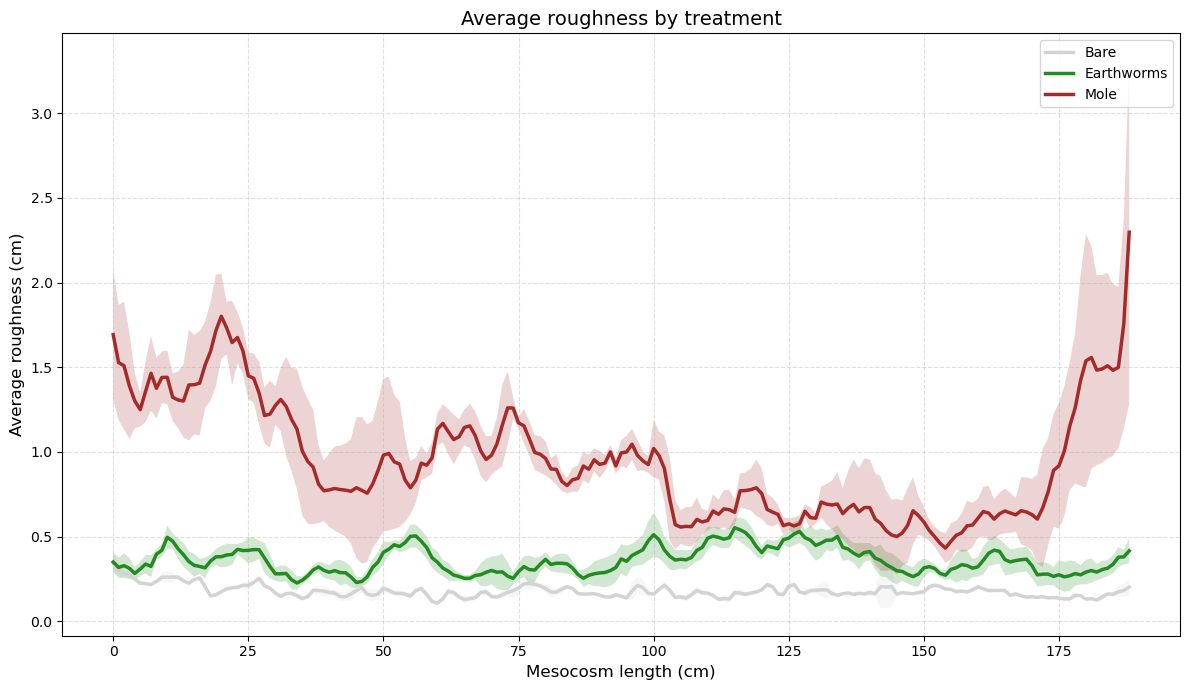

In [64]:
# 1. Setup grouping containers
treatment_groups = {'B': [], "EW": [], "M": []}


# 2. Collect and group the data
for name, df in roughness_data.items():
    run = rough_mapping.get(name)
    
    if run and 'mean_surf_change_row (m)' in df.columns:
        
        # Extract treatment (before underscore)
        treatment = run.split("_")[0]
        
        series = df['mean_surf_change_row (m)'] * 100
        treatment_groups[treatment].append(series)
        
    else:
        print(f"Skipping or Warning: {name}")


# 3. Plotting
plt.figure(figsize=(12, 7))

colors = {"B": "lightgray", "EW": "forestgreen", "M": "brown"}
labels = {"B": "Bare", "EW": "Earthworms", "M": "Mole"}

for treat, series_list in treatment_groups.items():
    if not series_list:
        continue
    
    # Combine list of series into a single DataFrame to calculate mean/std row-wise
    combined_df = pd.concat(series_list, axis=1)
    
    avg_line = combined_df.mean(axis=1)
    std_dev = combined_df.std(axis=1)
    x_axis = combined_df.index # Assuming index represents mesocosm length

    # Plot the Mean Line
    plt.plot(x_axis, avg_line, label=labels[treat], color=colors[treat], linewidth=2.5)

    # Plot the Variance Shade (Mean +/- 1 Standard Deviation)
    plt.fill_between(x_axis, 
                     avg_line - std_dev, 
                     avg_line + std_dev, 
                     color=colors[treat], 
                     alpha=0.2, 
                     edgecolor='none')
# 4. Styling
plt.title("Average roughness by treatment", fontsize=14)
plt.xlabel("Mesocosm length (cm)", fontsize=12)
plt.ylabel("Average roughness (cm)", fontsize=12)
#plt.axhline(0, color='black', linewidth=1, linestyle='-') # Reference line at 0
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()  

In [65]:
# 1. Setup grouping containers and prepare data structure for slope sections and treatments

data = {
    "Upslope": {"Bare": [], "Earthworms": [], "Mole": []},
    "Middle": {"Bare": [], "Earthworms": [], "Mole": []},
    "Downslope": {"Bare": [], "Earthworms": [], "Mole": []}
}

treatment_groups = {'B': [], "EW": [], "M": []}
treatment_name_map = {
    "B": "Bare",
    "EW": "Earthworms",
    "M": "Mole"
}

# 2. Collect and group the data by slope section and treatment

for name, df in roughness_data.items():
    run = rough_mapping.get(name)

    if not run:
        print(f"Skipping: {name} (no mapping)")
        continue
        
    if 'mean_surf_change_row (m)' not in df.columns:
        print(f"Skipping: {name} (column missing)")
        continue

    treatment_code = run.split("_")[0]
    treatment = treatment_name_map[treatment_code]

    values_cm = df['mean_surf_change_row (m)'] * 100 # convert to cm
    values_cm = values_cm.dropna()

    n_rows = len(values_cm)
    third = n_rows // 3

    back = values_cm.iloc[:third]
    middle = values_cm.iloc[third:2*third]
    front = values_cm.iloc[2*third:]

    data["Upslope"][treatment].append(back.mean())
    data["Middle"][treatment].append(middle.mean())
    data["Downslope"][treatment].append(front.mean())
     

Skipping: Rough_1cm_Detrended_clip_4_masked (no mapping)
Skipping: Rough_1cm_Detrended_clip_4 (no mapping)
Skipping: Rough_1cm_Detrended_clip_16 (no mapping)


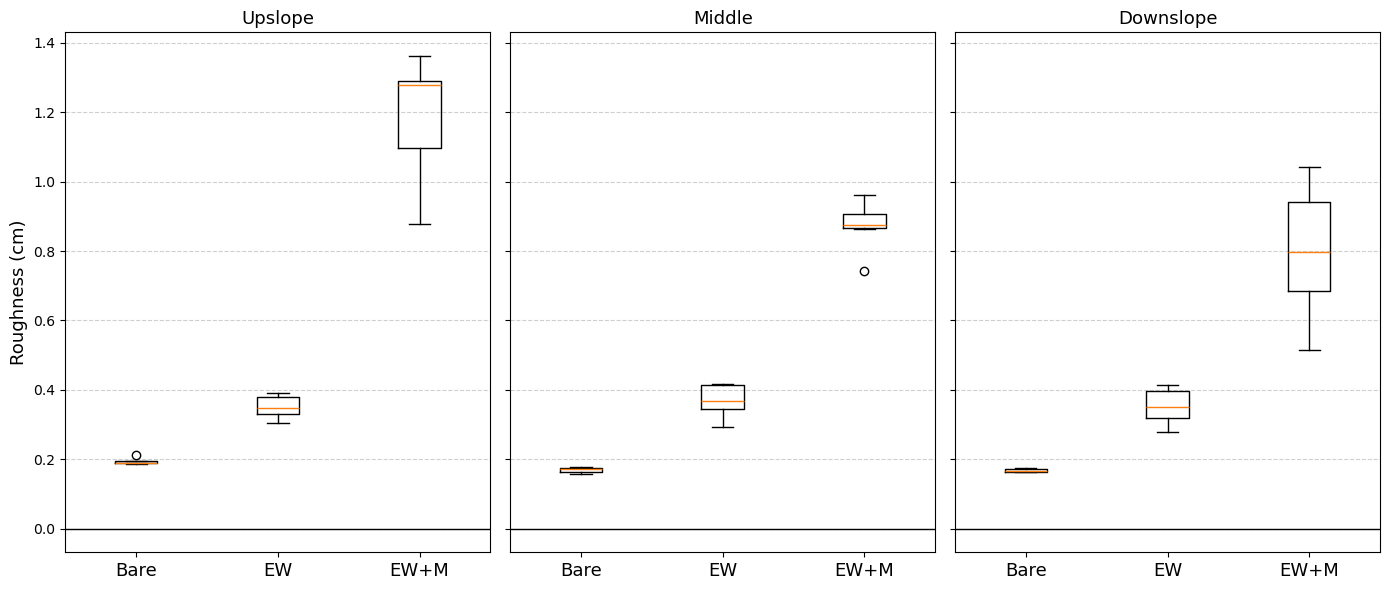

In [72]:
# Boxplot visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)

zones = ["Upslope", "Middle", "Downslope"]
treatments = ["Bare", "Earthworms", "Mole"]
display_labels = ["Bare", "EW", "EW+M"]  # Shortened labels for all subplots

for i, zone in enumerate(zones): #[i] indicates the x axes
    zone_data = [data[zone][t] for t in treatments]
    axes[i].boxplot(zone_data, labels=display_labels, showfliers=True)
    axes[i].tick_params(axis='x', labelsize=13)
    axes[i].axhline(0, color='black', linewidth=1)
    axes[i].set_title(zone, fontsize=13)
    
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

axes[0].set_ylabel("Roughness (cm)", fontsize = 13)

#plt.suptitle("Roughness (cm)", fontsize=14)
plt.tight_layout()
plt.show()


Calculate the percentage of change among treatments

In [ ]:
zone_means = {}

for zone, treatments in data.items():
    zone_means[zone] = {}
    for treatment, values in treatments.items():
        zone_means[zone][treatment] = np.mean(values)

In [ ]:
zone_means["Upslope"]["Bare"]
zone_means["Upslope"]["Earthworms"]
zone_means["Upslope"]["Mole"]

In [ ]:
# Calculate percentage change compared to Bare for each treatment and zone
percent_change = {}

for zone, treatments in zone_means.items():
    bare = treatments["Bare"]
    earthworms = treatments["Earthworms"]
    mole = treatments["Mole"]
    
    percent_change[zone] = {
        "EW_vs_Bare": ((earthworms - bare) / bare) * 100,
        "Mole_vs_Bare": ((mole - bare) / bare) * 100,
        "Mole_vs_EW": ((mole - earthworms) / earthworms) * 100
    }

#print results
for zone, comparisons in percent_change.items():
    print(f"\n{zone}")
    for comp, value in comparisons.items():
        print(f"{comp}: {value:.2f}%")

# Quick check
for zone in zone_means:
    print(zone)
    print(zone_means[zone])

# Visualization of potential sediment redistribution

Aim of this code: visualize the magnitude of sediment movement and where the sediment eroded/deposited.
Explanation:
1. The "Magnitude": in fluid dynamics, magnitude is the length of the quiver arrow. However, in soil science, the "magnitude" of movement is usually the volume change (DoD values). By using the DoD as the color-mapped background and the arrows for direction, we are visualizing a 3-variable system (X, Y, and $\Delta Z$).
2. Resolution vs. Noise: if soil surface is very rough (cloddy), the np.gradient will produce very chaotic arrows. If the plot looks "messy," apply a slight Gaussian Blur (scipy.ndimage.gaussian_filter) to the DEM before calculating the gradient to capture the general flow rather than the micro-topography of every single pebble.
3. Local vs. Global Coordinates: Since we are using a local system, origin='lower' in imshow is critical. It ensures that $(0,0)$ is the bottom-left corner of your physical plot.
4. Arrows show the local direction of steepest descent of the DEM, not measured sediment transport; and pixels are shown at reduced opacity below the LoD rather than removed, with the dashed lines on each colorbar marking ±LoD.

In [ ]:
# -------------------------------
#  DATA MAPPING
# -------------------------------
dod_map = {
    'B_AR2-BR2': "DoD_1cm_clip_4_masked_filled-3_fill.tif",
    'B_AR3-BR3': "DoD_1cm_clip_6fill_align-clip_5fill_align.tif",
    'EW_AR1-BR1': "DoD_1cm_clip_11-10.tif",
    'EW_AR2-BR2': 'DoD_1cm_clip_13-12.tif',
    'EW_AR3-BR3': 'DoD_1cm_clip_15-14.tif',
    'EW_AR4-BR4': 'DoD_1cm_clip_17-16.tif',
    'EW+M_AR1-BR1': 'DoD_1cm_clip_21-20.tif',
    'EW+M_AR2-BR2': 'DoD_1cm_clip_23-22.tif',
    'EW+M_AR3-BR3': 'DoD_1cm_clip_25-24.tif',
}

dem_map = {
    'B_AR2': '1cm_clip_4_masked_filled.tif',
    'B_AR3': '1cm_clip_6fill-align.tif',
    'EW_AR1': '1cm_clip_11.tif',
    'EW_AR2': '1cm_clip_13.tif',
    'EW_AR3': '1cm_clip_15.tif',
    'EW_AR4': '1cm_clip_17.tif',
    'EW+M_AR1': '1cm_clip_21.tif',
    'EW+M_AR2': '1cm_clip_23.tif',
    'EW+M_AR3': '1cm_clip_25.tif'
}

# LoD values in meters
lod_values = {
    'B_AR2-BR2': 0.002,
    'B_AR3-BR3': 0.003,
    'EW_AR1-BR1': 0.004,
    'EW_AR2-BR2': 0.006,
    'EW_AR3-BR3': 0.004,
    'EW_AR4-BR4': 0.003,
    'EW+M_AR1-BR1': 0.006,
    'EW+M_AR2-BR2': 0.003,
    'EW+M_AR3-BR3': 0.004,
}

dod_folder = r"C:\\DoD_1cm_nodetrended_z"
dem_folder = r"C:\\DEM_1cm_z"


B_AR2-BR2      DEM: after (AR)   LoD=2 mm | Ero   -3864.8 (raw   -3983.3) | Dep      80.7 (raw     153.7) cm3
B_AR3-BR3      DEM: after (AR)   LoD=3 mm | Ero      -4.9 (raw     -43.9) | Dep      83.9 (raw    1412.4) cm3
EW_AR1-BR1     DEM: after (AR)   LoD=4 mm | Ero   -1637.5 (raw   -2642.8) | Dep       1.0 (raw      57.7) cm3
EW_AR2-BR2     DEM: after (AR)   LoD=6 mm | Ero    -629.9 (raw   -1831.5) | Dep     255.0 (raw     893.3) cm3
EW_AR3-BR3     DEM: after (AR)   LoD=4 mm | Ero   -1761.6 (raw   -2514.9) | Dep      10.4 (raw     191.0) cm3
EW_AR4-BR4     DEM: after (AR)   LoD=3 mm | Ero   -2038.3 (raw   -2383.3) | Dep      33.5 (raw      59.6) cm3
EW+M_AR1-BR1   DEM: after (AR)   LoD=6 mm | Ero  -14014.1 (raw  -14066.2) | Dep       1.2 (raw       5.7) cm3
EW+M_AR2-BR2   DEM: after (AR)   LoD=3 mm | Ero   -6008.5 (raw   -6382.8) | Dep      20.3 (raw      50.5) cm3
EW+M_AR3-BR3   DEM: after (AR)   LoD=4 mm | Ero   -6590.8 (raw   -7064.2) | Dep      85.5 (raw     210.0) cm3

=== Share

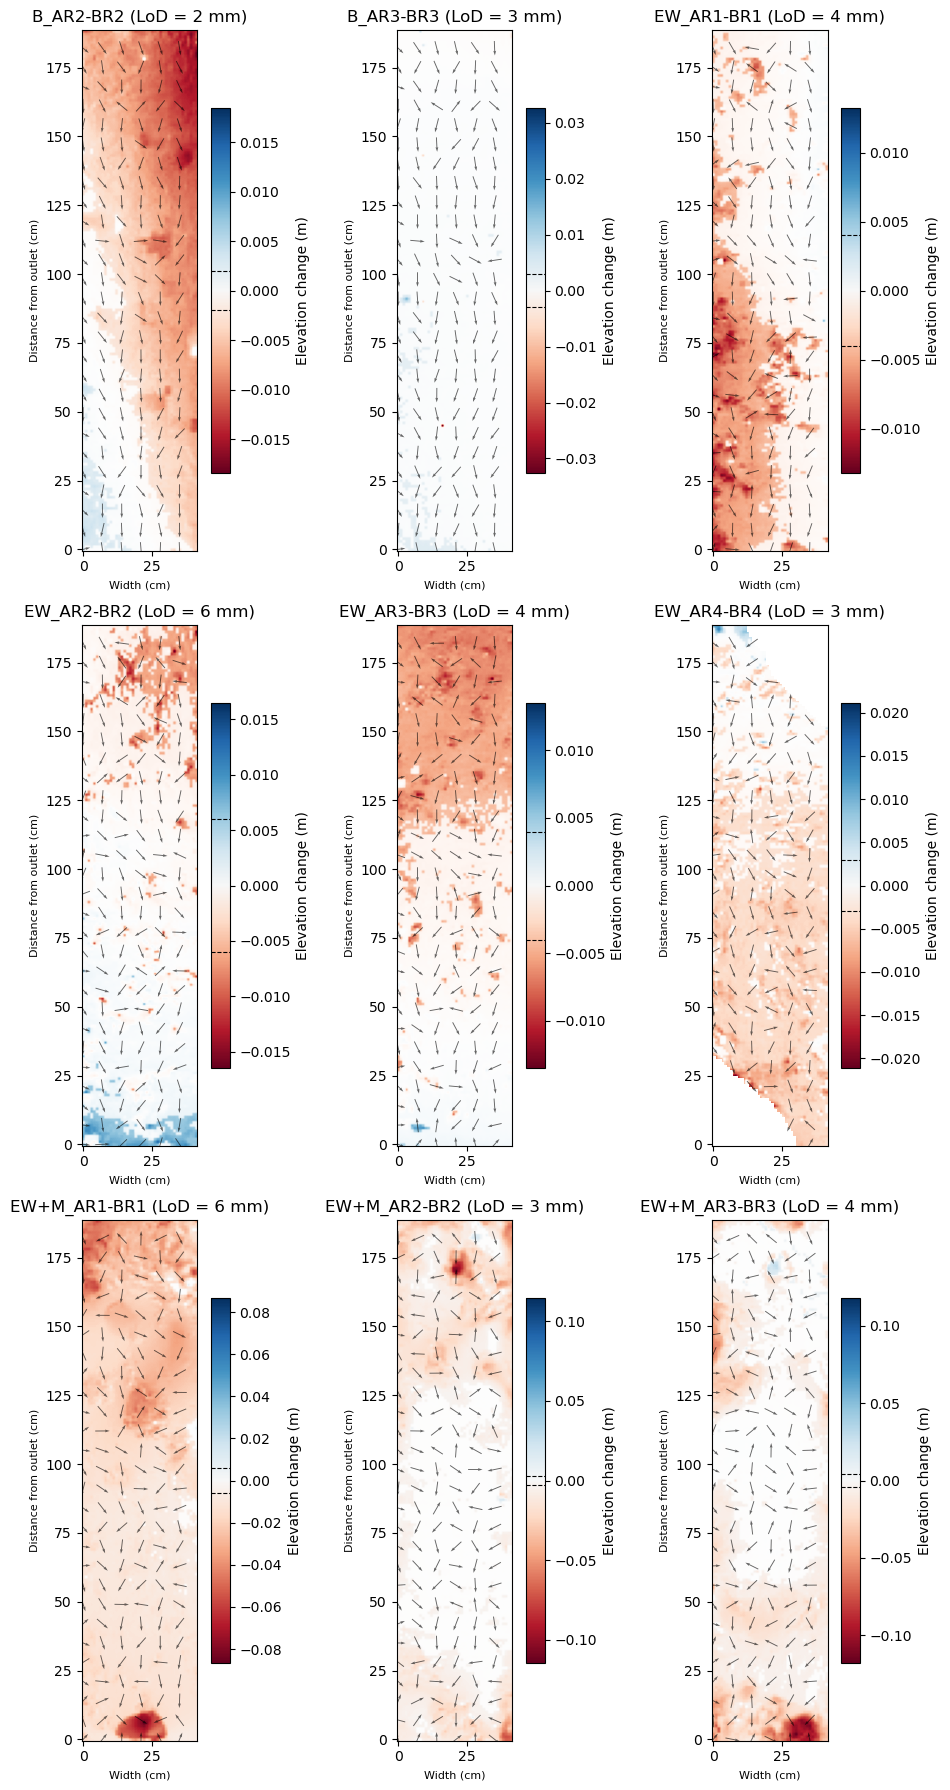

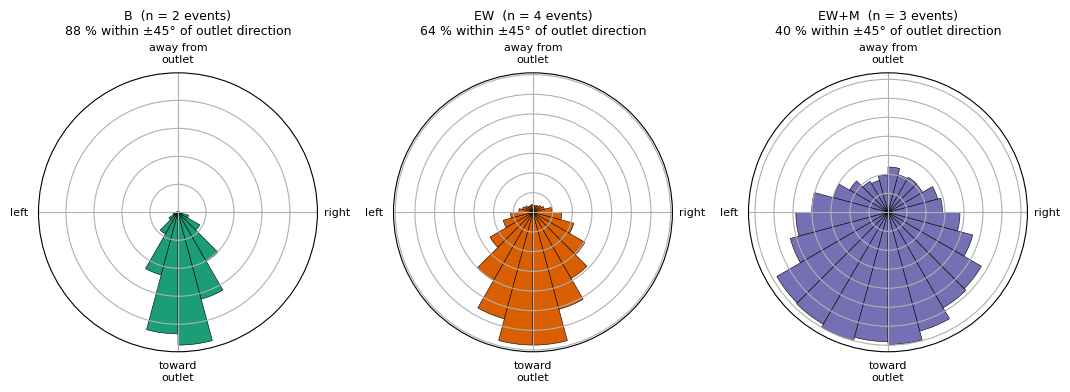

In [4]:

# ---------------------------------------------------------------------
# USER SETTINGS - main changes shall be done here, not in the functions below
# ---------------------------------------------------------------------
PIXEL_SIZE = 0.01              # m (1 cm)

# Arrows
SIGMA_ARROWS = None            # None = no smoothing (px). Smoothing changes what the arrows mean -> report it.
STEP_OVERVIEW = 7              # arrow spacing in the full-panel figure (px = cm)
ARROW_FRAC = 0.75              # arrow length as a fraction of the spacing
MIN_SLOPE = 0.0                # m/m; hide arrows (and ignore pixels in the statistics) at/below this slope
ARROWS_ONLY_WHERE_SIGNIFICANT = False #True   # overview: arrows only where |DoD| >= LoD


# Colours
COLOR_LIMIT = "panel"         # "shared" | "panel" | number (m): to decide the colour range of the DoD raster in the overview figure

# Statistics: gaussian smoothing scales (px) at which direction statistics are reported (scale check)
STATS_SIGMAS = [None, 1, 2, 4]


OUT_DIR = "."                  # where PNG/CSV are saved
SAVE_FIGS = True

# ---------------------------------------------------------------------
# 1. BASIC FUNCTIONS
# ---------------------------------------------------------------------
def load_tif(file_path):
    """Load a single-band TIF as float array with NaN for NoData."""
    with rasterio.open(file_path) as src:
        data = src.read(1).astype(float)
        if src.nodata is not None:
            data = np.where(data == src.nodata, np.nan, data)
    return data


def apply_lod(dod, lod):
    """Mask values within ±LoD."""
    out = dod.copy()
    out[np.abs(out) < lod] = np.nan
    return out

def nan_gaussian(a, sigma):
    """Gaussian smoothing that ignores NaN (normalised convolution) and keeps the NaN footprint."""
    ok = np.isfinite(a)
    num = gaussian_filter(np.where(ok, a, 0.0), sigma)
    den = gaussian_filter(ok.astype(float), sigma)
    with np.errstate(invalid="ignore", divide="ignore"):
        out = num / den
    out[~ok] = np.nan
    return out


def compute_gradient(dem, sigma=None, pixel_size=PIXEL_SIZE):
    """
    Gradient in ARRAY axes, as true slope (m/m):
        dy = dz/d(row)  -> row 0 is the outlet, so +dy means rising AWAY from the outlet
        dx = dz/d(col)
    """
    if sigma is not None:
        dem = nan_gaussian(dem, sigma)
    dy, dx = np.gradient(dem, pixel_size)
    return dx, dy


def plane_detrended_rms(dem, valid, pixel_size=PIXEL_SIZE):
    """RMS height (m) after removing a best-fit plane = roughness index."""
    rr, cc = np.mgrid[0:dem.shape[0], 0:dem.shape[1]]
    A = np.c_[rr[valid] * pixel_size, cc[valid] * pixel_size, np.ones(valid.sum())]
    coef, *_ = np.linalg.lstsq(A, dem[valid], rcond=None)
    return np.sqrt(np.mean((dem[valid] - A @ coef) ** 2))


def direction_stats(dem, footprint, sigma=None, min_slope=MIN_SLOPE):
    """
    R          : |mean gradient vector| / mean |gradient|   (1 = every pixel drains the same way, ~0 = no preferred direction)
    frac_off45 : fraction of pixels whose steepest-descent direction deviates > 45 deg from the MEAN downslope direction
    (random directions would give 0.75)
    """
    dx, dy = compute_gradient(dem, sigma=sigma)
    slope = np.hypot(dx, dy)
    use = footprint & np.isfinite(slope) & (slope > min_slope)
    if use.sum() < 50:
        return dict(R=np.nan, frac_off45=np.nan, mean_slope=np.nan, n_px=int(use.sum()))
    gx, gy = dx[use], dy[use]
    R = np.hypot(gx.mean(), gy.mean()) / slope[use].mean()
    theta = np.arctan2(-gy, -gx)
    phi = np.arctan2(-gy.mean(), -gx.mean())
    dev = np.abs(np.angle(np.exp(1j * (theta - phi))))
    return dict(R=R, frac_off45=np.mean(dev > np.pi / 4), mean_slope=slope[use].mean(), n_px=int(use.sum()))


# ---------------------------------------------------------------------
# 2. PER-EVENT CALCULATION (no plotting)
# ---------------------------------------------------------------------
def calculate_treatment_data(dem_path, dod_path, label, lod_value, dem_used):
    dem = load_tif(dem_path)
    dod = load_tif(dod_path)
    if dem.shape != dod.shape:
        raise ValueError(f"{label}: DEM {dem.shape} and DoD {dod.shape} differ in shape")

    dod_filt = apply_lod(dod, lod_value)                 # everything 'significant' uses this
    footprint = np.isfinite(dod) & np.isfinite(dem)      # valid area (raw DoD footprint) for statistics

    # --- arrows: steepest descent, unit length ---
    dx, dy = compute_gradient(dem, sigma=SIGMA_ARROWS)
    slope = np.hypot(dx, dy)
    with np.errstate(invalid="ignore", divide="ignore"):
        dxu, dyu = dx / slope, dy / slope
    ok_slope = np.isfinite(slope) & (slope > MIN_SLOPE)

    # Plot frame: x = column (right), y = row (row 0 = OUTLET at the BOTTOM).
    # y_plot increases with the row index, so the downhill vector is simply (-dz/dcol, -dz/drow).
    show_sig = np.isfinite(dod_filt) & ok_slope
    show_all = footprint & ok_slope
    u, v = np.where(show_sig, -dxu, np.nan), np.where(show_sig, -dyu, np.nan)
    u_all, v_all = np.where(show_all, -dxu, np.nan), np.where(show_all, -dyu, np.nan)

    # --- coordinates (cm, pixel centres) ---
    n_rows, n_cols = dem.shape
    cell_cm = PIXEL_SIZE * 100
    col, row = np.meshgrid(np.arange(n_cols), np.arange(n_rows))
    x, y = col * cell_cm, row * cell_cm
    extent = [-0.5 * cell_cm, (n_cols - 0.5) * cell_cm, -0.5 * cell_cm, (n_rows - 0.5) * cell_cm]

    # --- volumes (m3) ---
    A_px = PIXEL_SIZE ** 2
    vol = lambda d: (np.nansum(np.where(d < 0, d, 0)) * A_px, np.nansum(np.where(d > 0, d, 0)) * A_px)
    ero, dep = vol(dod_filt)
    ero_raw, dep_raw = vol(dod)

    # --- direction statistics at several smoothing scales + roughness ---
    rms_h = plane_detrended_rms(dem, footprint & np.isfinite(dem))
    stats = []
    for s in STATS_SIGMAS:
        d = direction_stats(dem, footprint, sigma=s)
        d.update(sigma_px=("none" if s is None else s))
        stats.append(d)

    # slope-weighted direction of every pixel (for the rose diagrams), same DEM/smoothing as the arrows
    use = footprint & ok_slope
    theta = np.arctan2(-dy[use], -dx[use])     # angle in the plot frame; -90 deg (bottom) = toward the outlet
    weights = slope[use]

    return dict(label=label, group=label.split("_")[0], dem_used=dem_used, dem=dem,
                dod=dod_filt, dod_raw=dod, footprint=footprint,
                u=u, v=v, u_all=u_all, v_all=v_all, x=x, y=y, extent=extent,
                cell_cm=cell_cm, lod=lod_value, rms_h=rms_h, stats=stats,
                theta=theta, w=weights,
                erosion=ero, deposition=dep, erosion_raw=ero_raw, deposition_raw=dep_raw,
                pct_above_lod=100 * np.isfinite(dod_filt).sum() / max(1, np.isfinite(dod).sum()))


# ---------------------------------------------------------------------
# 3. BATCH
# ---------------------------------------------------------------------
results = []
for dod_label, dod_filename in dod_map.items():
    dem_label = dod_label.split("-")[0]                  
    if dem_label not in dem_map:
        print(f"Warning: no DEM for {dod_label} -> skipped"); continue
    dem_file, dem_used = dem_map[dem_label], "after (AR)"

    data = calculate_treatment_data(os.path.join(dem_folder, dem_file),
                                    os.path.join(dod_folder, dod_filename),
                                    dod_label, lod_values[dod_label], dem_used)
    results.append(data)
    print(f"{dod_label:14s} DEM: {dem_used:12s} LoD={data['lod']*1000:.0f} mm | "
          f"Ero {data['erosion']*1e6:9.1f} (raw {data['erosion_raw']*1e6:9.1f}) | "
          f"Dep {data['deposition']*1e6:9.1f} (raw {data['deposition_raw']*1e6:9.1f}) cm3")

# rose summary: share of slope-weighted mass within +-45 deg of the direction TOWARD the outlet (-90 deg)
def pct_toward_outlet(theta, w):
    dev = np.abs(np.angle(np.exp(1j * (theta + np.pi / 2))))
    return 100 * w[dev <= np.pi / 4].sum() / w.sum()

groups = list(dict.fromkeys(d["group"] for d in results))
print("\n=== Share of slope-weighted descent directions within +-45 deg of the outlet direction ===")
for g in groups:
    th = np.concatenate([d["theta"] for d in results if d["group"] == g])
    ww = np.concatenate([d["w"] for d in results if d["group"] == g])
    print(f"{g:6s}: {pct_toward_outlet(th, ww):5.1f} %")

#if SAVE_FIGS:
#    os.makedirs(OUT_DIR, exist_ok=True)
#    stats_df.to_csv(os.path.join(OUT_DIR, "direction_statistics.csv"), index=False)


# ---------------------------------------------------------------------
# FIGURE 1 - OVERVIEW: DoD (above LoD) + steepest-descent arrows, outlet at the bottom
# ---------------------------------------------------------------------
def _abs_max(a):
    return np.nanmax(np.abs(a)) if np.isfinite(a).any() else np.nan

if COLOR_LIMIT == "shared": # give the same colour range to all panels (comparable between treatments)
    global_lim = np.nanmax([_abs_max(d["dod_raw"]) for d in results])
elif isinstance(COLOR_LIMIT, (int, float)):
    global_lim = float(COLOR_LIMIT)
else:
    global_lim = None

cmap = plt.get_cmap("RdBu").copy()
#cmap.set_bad("lightgrey") # lightgreen for missing data


def add_arrows(ax, d, step, sl_r, sl_c, all_pixels, width, color, alpha):
    """Arrows sampled every `step` px inside the window sl_r x sl_c; centred (pivot='mid') on the pixel centre."""
    U = (d["u_all"] if all_pixels else d["u"])[sl_r, sl_c][::step, ::step]
    V = (d["v_all"] if all_pixels else d["v"])[sl_r, sl_c][::step, ::step]
    X = d["x"][sl_r, sl_c][::step, ::step]
    Y = d["y"][sl_r, sl_c][::step, ::step]
    width_cm = d["x"][sl_r, sl_c].max() - d["x"][sl_r, sl_c].min() + d["cell_cm"]
    scale = width_cm / (ARROW_FRAC * step * d["cell_cm"])       # arrow length = ARROW_FRAC * spacing
    ax.quiver(X, Y, U, V, color=color, alpha=alpha, width=width, scale=scale, pivot="mid")

cols = 3
rows = (len(results) + cols - 1) // cols
fig1, axes = plt.subplots(rows, cols, figsize=(10, 6 * rows), squeeze=False)

# Define transparency factor for values < LoD 
BELOW_LOD_ALPHA = 0.20

for idx, d in enumerate(results):
    ax = axes[divmod(idx, cols)]

    # Color limits using raw DoD map
    lim = global_lim if global_lim is not None else _abs_max(d["dod_raw"])
    if not np.isfinite(lim) or lim == 0:
        lim = 1e-3
    # --- Build pixel-wise Alpha Channel using raw DoD and dataset LoD ---
    raw_dod = d["dod_raw"]
    lod_val = d["lod"]

    alpha_mask = np.ones_like(raw_dod, dtype=float)
    # Set pixels below the dataset's specific LoD to low alpha
    below_lod = np.abs(raw_dod) < lod_val
    alpha_mask[below_lod] = BELOW_LOD_ALPHA

    # Hide invalid NaN background pixels
    alpha_mask[~np.isfinite(raw_dod)] = 0.0

    # Plot image with dynamic alpha mask:
    
    im = ax.imshow(
        raw_dod, 
        cmap=cmap, 
        origin="lower", 
        extent=d["extent"],
        vmin=-lim, 
        vmax=lim, 
        aspect="equal",
        alpha=alpha_mask  # Pass constructed dynamic alpha mask
    )
    
    add_arrows(ax, d, STEP_OVERVIEW, slice(None), slice(None),
               all_pixels=not ARROWS_ONLY_WHERE_SIGNIFICANT, width=0.008, color="black", alpha=0.6)
    ax.set_title(f"{d['label']} (LoD = {lod_val*1000:.0f} mm)")
    ax.set_xlabel("Width (cm)", fontsize=8)
    ax.set_ylabel("Distance from outlet (cm)", fontsize=8)
    
    cbar = fig1.colorbar(im, ax=ax, label="Elevation change (m)", shrink=0.7)
     # Indicate the limit of detection (LoD) with dashed lines on the colorbar
    cbar.ax.axhline(lod_val, color="black", linestyle="--", linewidth=0.8)
    cbar.ax.axhline(-lod_val, color="black", linestyle="--", linewidth=0.8)
for idx in range(len(results), rows * cols):
    fig1.delaxes(axes[divmod(idx, cols)])

fig1.tight_layout()
#if SAVE_FIGS:
#    fig1.savefig(os.path.join(OUT_DIR, "fig1_DoD_arrows_overview.png"), dpi=300)
plt.show()


# ---------------------------------------------------------------------
# FIGURE 4 - rose diagrams of steepest-descent direction (slope-weighted), outlet at the bottom
# ---------------------------------------------------------------------
palette = dict(zip(groups, ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e"]))
fig4, raxes = plt.subplots(1, len(groups), figsize=(3.6 * len(groups), 3.8),
                           subplot_kw={"projection": "polar"}, squeeze=False)
bins = np.linspace(-np.pi, np.pi, 25)
for ax, g in zip(raxes[0], groups):
    th = np.concatenate([d["theta"] for d in results if d["group"] == g])
    ww = np.concatenate([d["w"] for d in results if d["group"] == g])
    h, _ = np.histogram(th, bins=bins, weights=ww)
    h = h / h.sum()
    ax.bar(0.5 * (bins[:-1] + bins[1:]), h, width=np.diff(bins), color=palette[g], edgecolor="k", linewidth=0.4)
    ax.set_yticklabels([])
    ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
    ax.set_xticklabels(["right", "away from\noutlet", "left", "toward\noutlet"], fontsize=8)
    ax.set_title(f"{g}  (n = {sum(d['group'] == g for d in results)} events)\n"
                 f"{pct_toward_outlet(th, ww):.0f} % within ±45° of outlet direction", fontsize=9)
fig4.tight_layout()
#if SAVE_FIGS:
#    fig4.savefig(os.path.join(OUT_DIR, "fig4_rose_descent_direction.png"), dpi=300)
plt.show()